<a href="https://colab.research.google.com/github/ushak1984/DX699-MODB2/blob/main/OMDS_ModB2_Week4_Krishnasamy_Usha_priya_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cybersecurity Univariate EDA and Distribution Analysis

**Author:** Usha Priya Krishnasamy  
**Project Type:** Exploratory data analysis and distribution visualization  
**Datasets:** BETH Honeypot, Cybersecurity Attacks Dataset, and UNSW-NB15  

## Project Overview

This notebook performs univariate exploratory data analysis across three public cybersecurity datasets used for threat detection and anomaly analysis.

The purpose is to examine feature distributions, categorical counts, class-label patterns, outliers, skewness, and grouped distribution behavior before building machine learning models.

This notebook supports a larger capstone project focused on cybersecurity attack classification and anomaly detection.

## Note

This version keeps the saved outputs and plots from the original run so the notebook can be reviewed on GitHub without rerunning the datasets.

The raw datasets are not included in this repository. The analysis was developed using public cybersecurity datasets.

## Analysis Plan

For each dataset, this notebook reviews:

- Histograms and distribution variants for numeric features
- KDE, violin, and swarm-style plots
- Grouped histograms using attack or label-related categories
- Bar plots for categorical variables
- Mean, median, and mode summaries
- Outlier review using the IQR method
- Short conclusions about distribution shape, skewness, class patterns, and modeling implications

### 1. BETH Honeypot Dataset

The BETH dataset contains host-level honeypot logs with process, host, user, event, suspicious-label, and malicious-label information.

The univariate analysis focuses on process activity, host activity, system-event distributions, suspicious behavior, malicious behavior, and feature patterns that may support attack classification or anomaly detection.

In [1]:
## Setup 
# Dataset loading

    #https://www.kaggle.com/datasets/katehighnam/beth-dataset
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

 

#!pip install kagglehub
import kagglehub
print("Kagglehub version:", kagglehub.__version__)
#!pip install --upgrade kagglehub


beth_dataset_path = kagglehub.dataset_download("katehighnam/beth-dataset")

print("Path to dataset files:", beth_dataset_path)

import os

# List all files in the dataset directory
print(os.listdir(beth_dataset_path))

# List of kernel log files- Merge and split the training,test and validation to balance classes ( evil=1 malicious activity)across the datasets
kernel_files = [
    "labelled_training_data.csv",
    "labelled_validation_data.csv",
    "labelled_testing_data.csv"
]

dataframes = [pd.read_csv(os.path.join(beth_dataset_path, file)) for file in kernel_files]
df_beth_merged = pd.concat(dataframes, ignore_index=True)

# Verify
df_train_val,df_test = train_test_split(df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42)
df_beth, df_val = train_test_split(df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42)




c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Kagglehub version: 0.3.13
Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\katehighnam\beth-dataset\versions\3
['labelled_2021may-ip-10-100-1-105-dns.csv', 'labelled_2021may-ip-10-100-1-105.csv', 'labelled_2021may-ip-10-100-1-186-dns.csv', 'labelled_2021may-ip-10-100-1-186.csv', 'labelled_2021may-ip-10-100-1-26-dns.csv', 'labelled_2021may-ip-10-100-1-26.csv', 'labelled_2021may-ip-10-100-1-4-dns.csv', 'labelled_2021may-ip-10-100-1-4.csv', 'labelled_2021may-ip-10-100-1-95-dns.csv', 'labelled_2021may-ip-10-100-1-95.csv', 'labelled_2021may-ubuntu-dns.csv', 'labelled_2021may-ubuntu.csv', 'labelled_testing_data.csv', 'labelled_training_data.csv', 'labelled_validation_data.csv']


c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 15.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


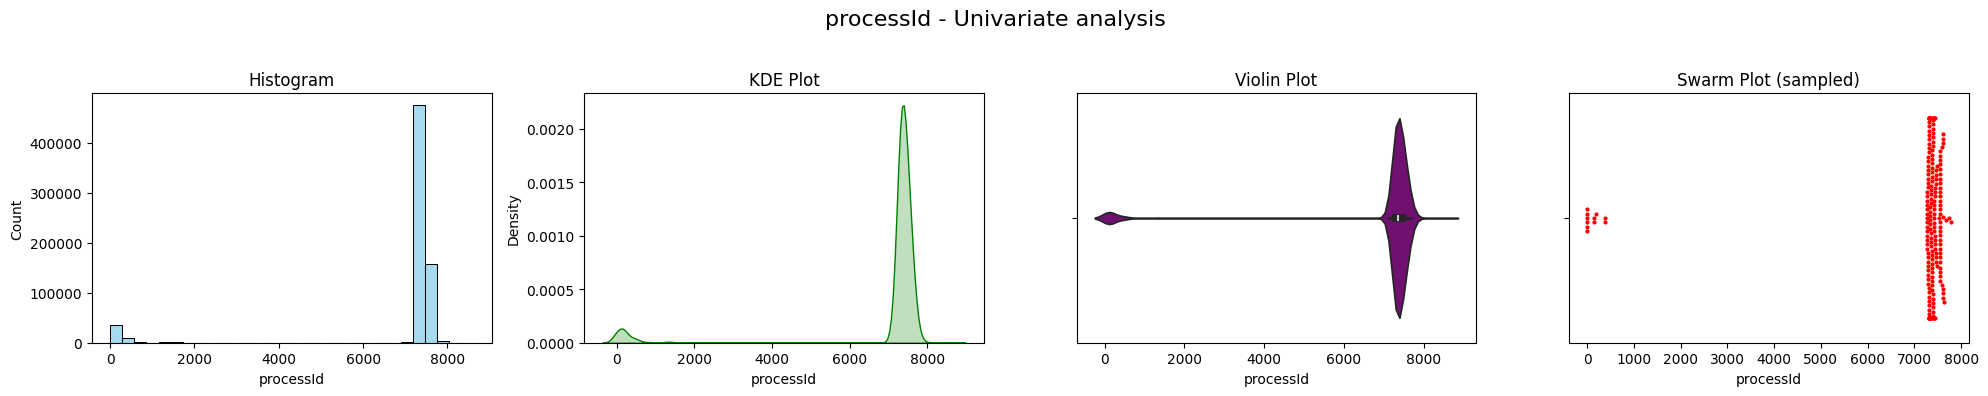

c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 15.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


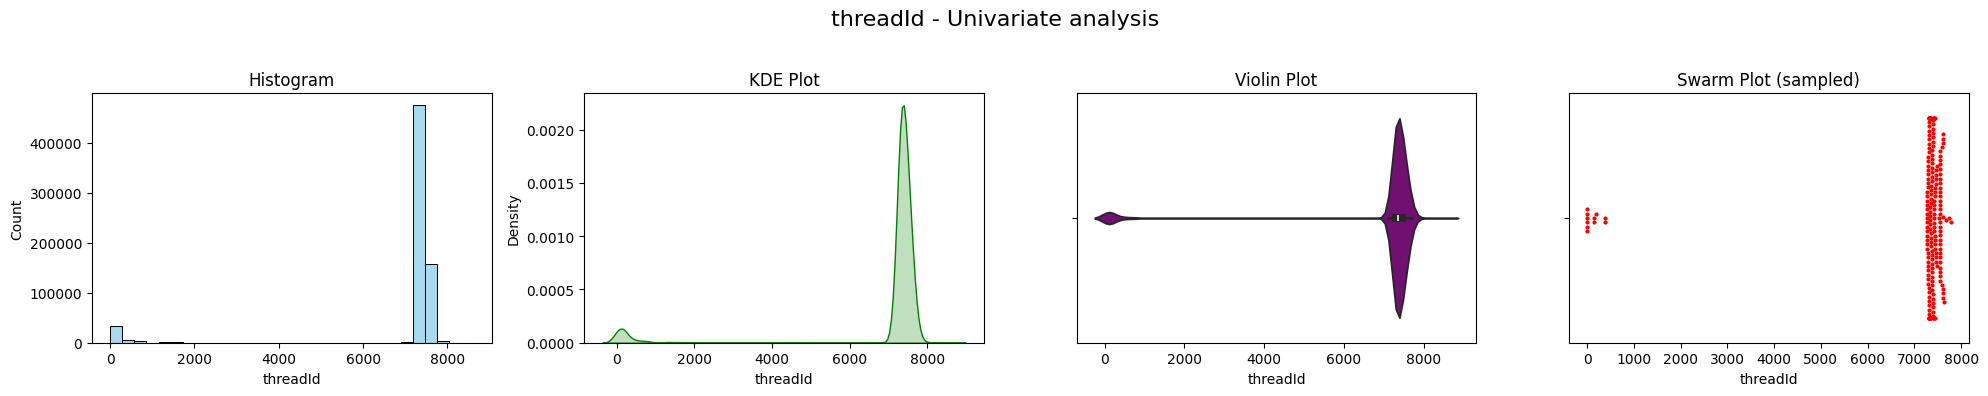

c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


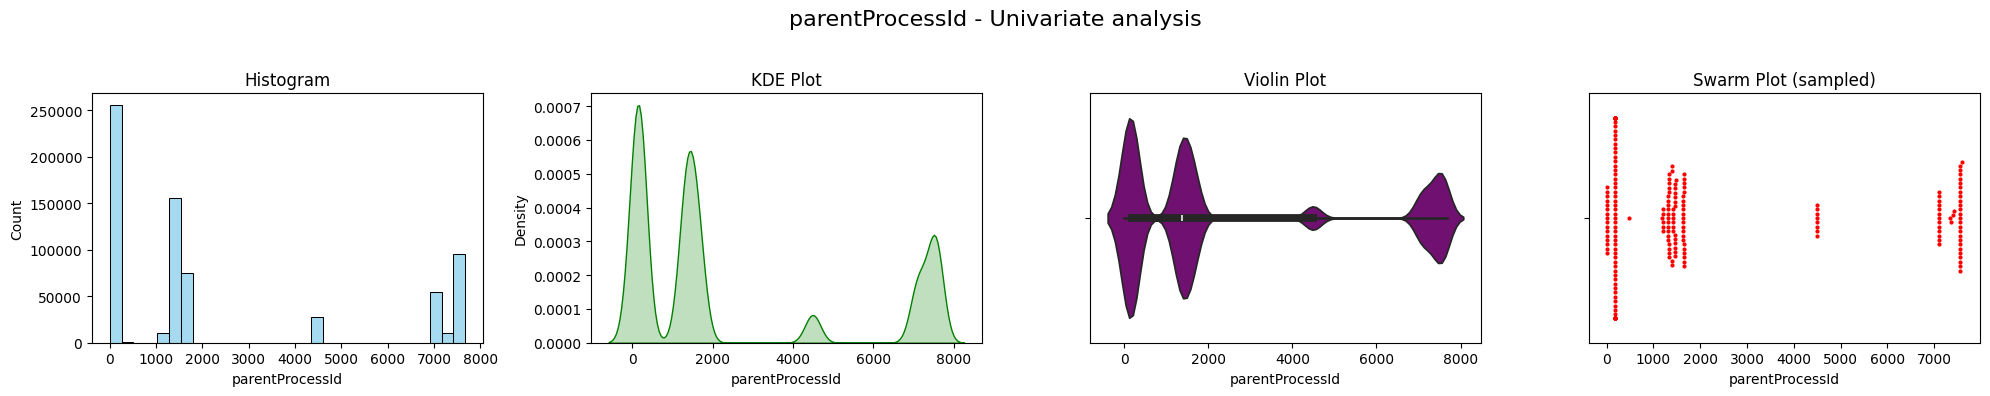

c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 62.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


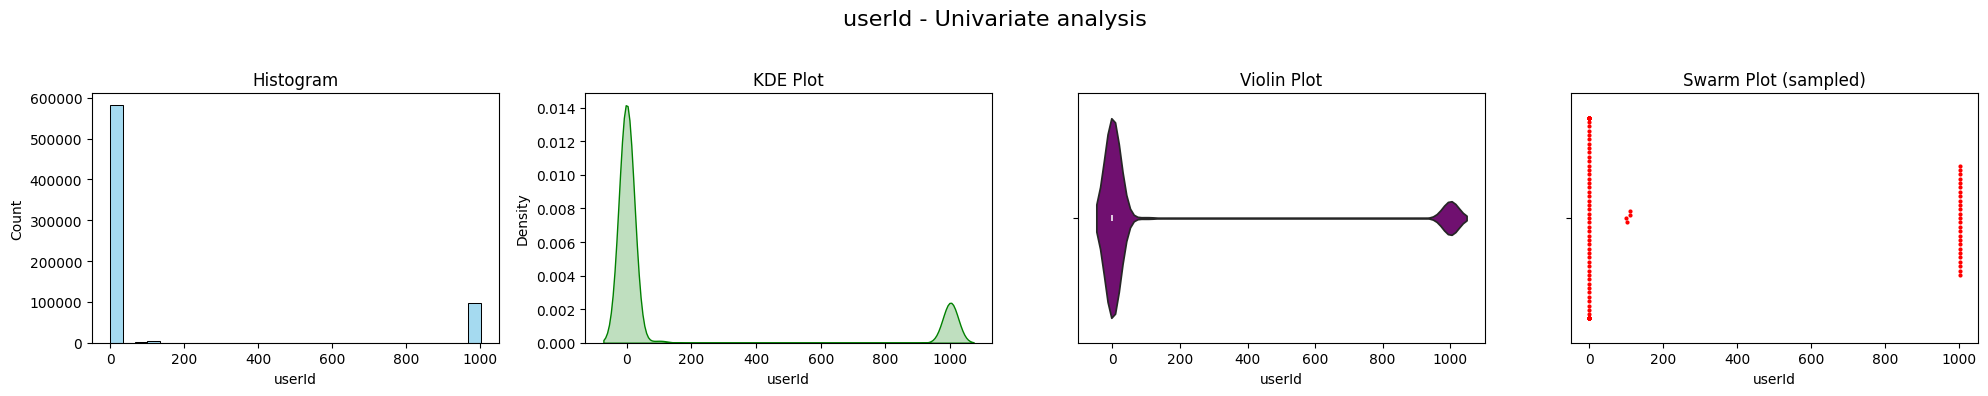

c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 54.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


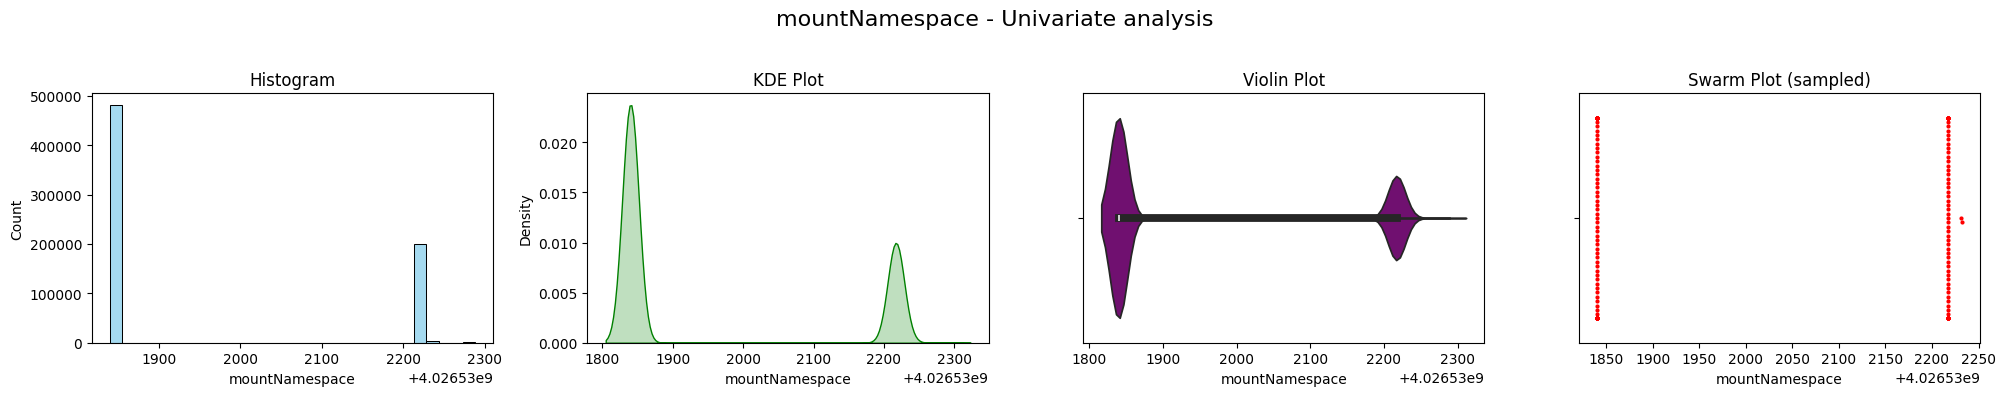

c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 19.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


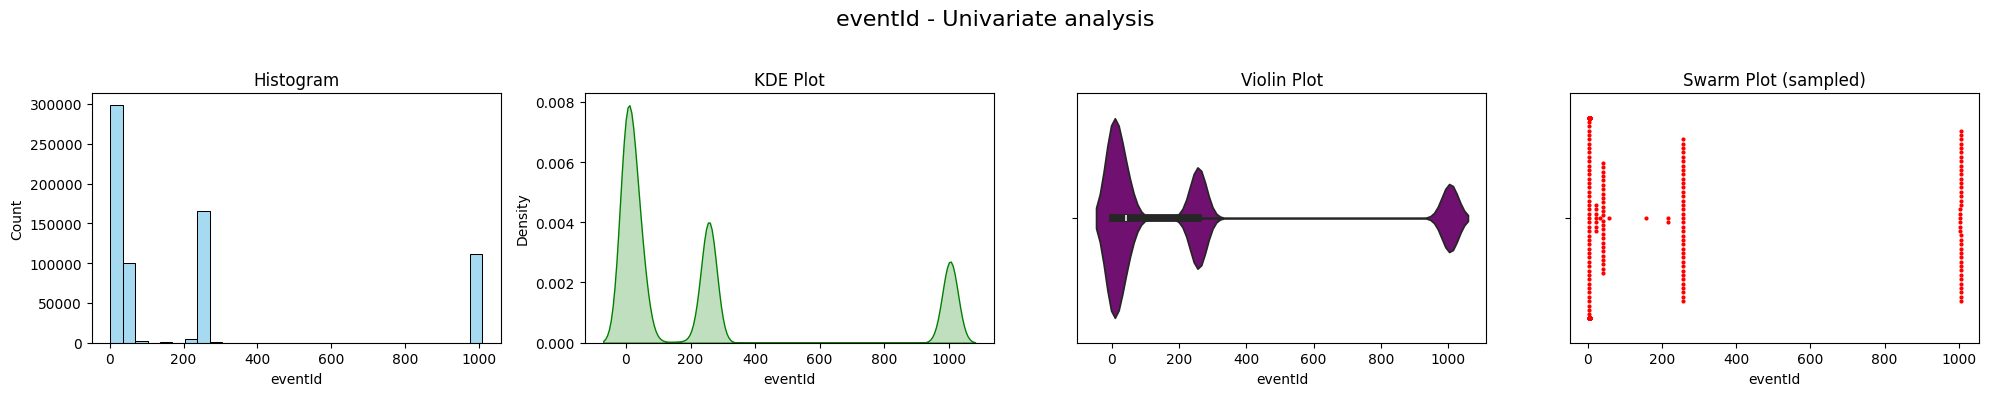

c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 65.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


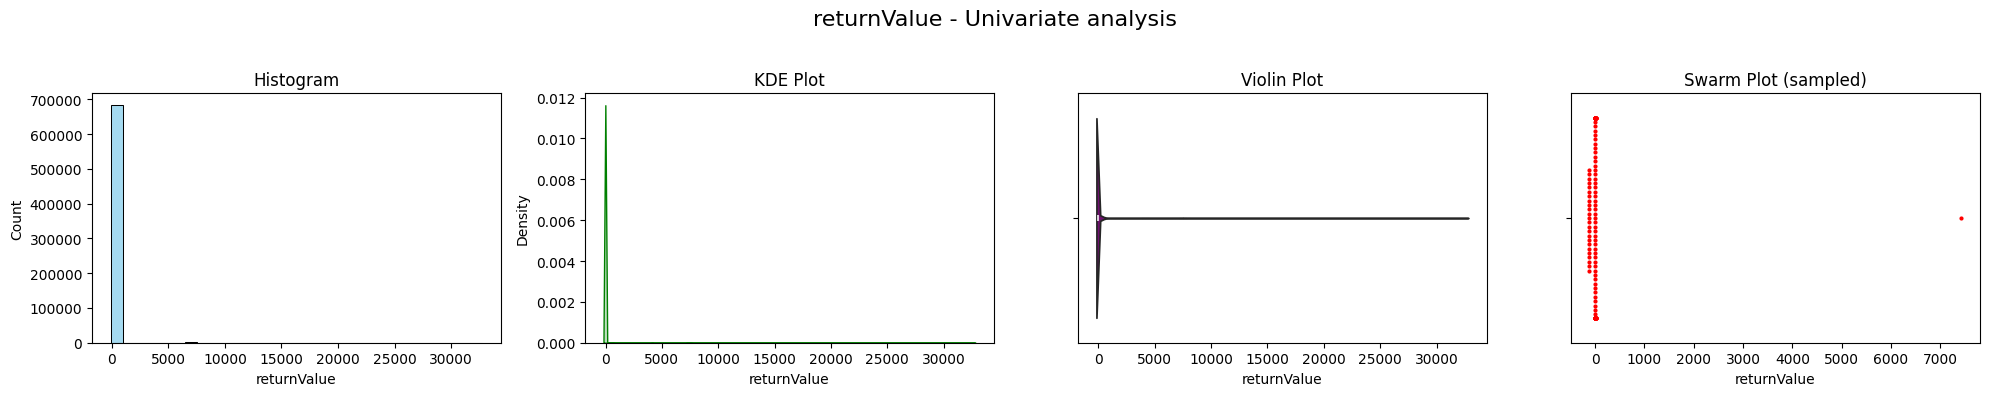

c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 64.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


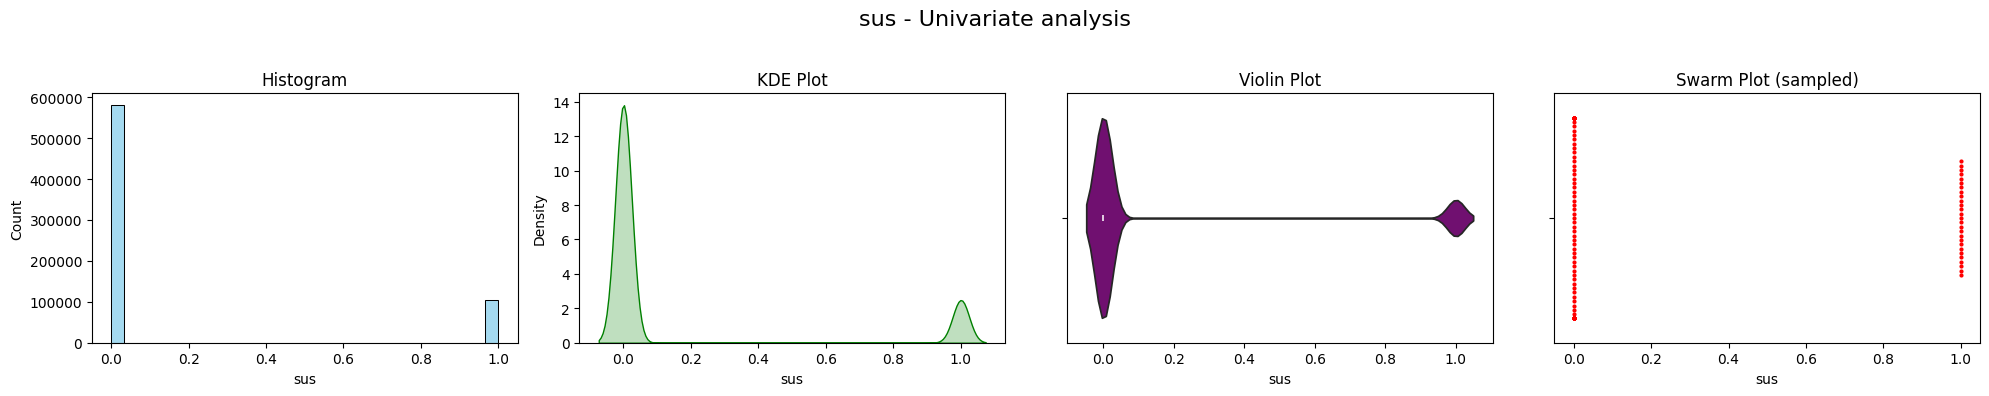

c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 64.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


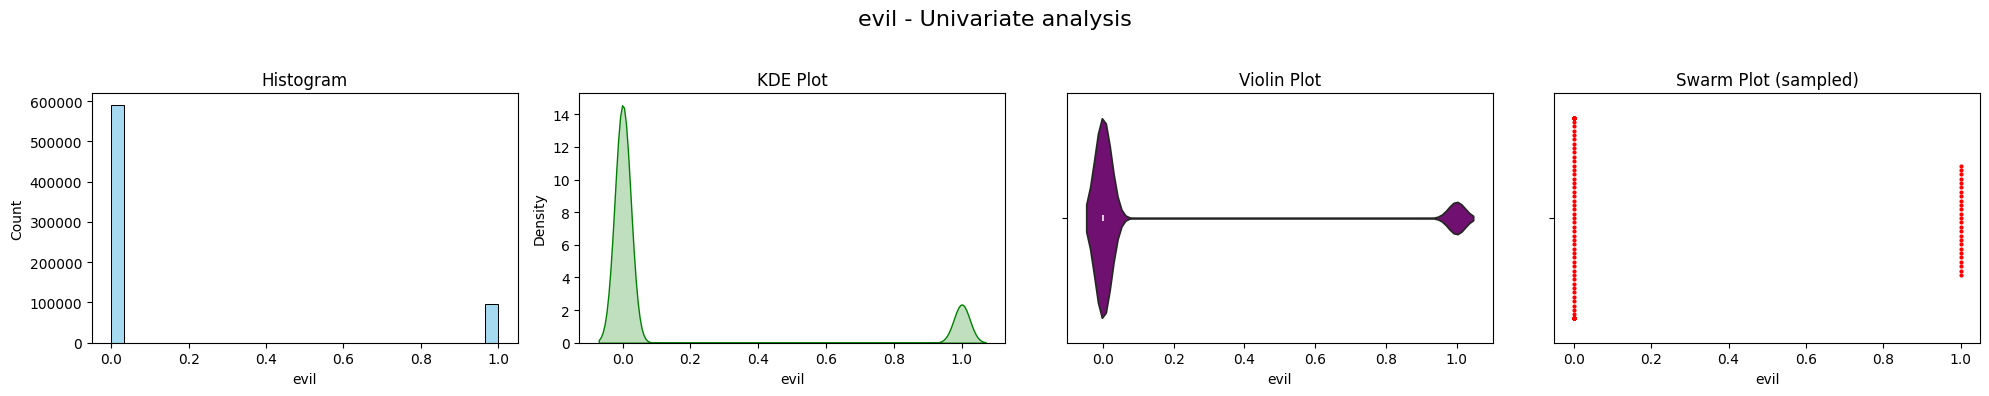

In [2]:
## Numeric Feature Distribution Analysis
import matplotlib.pyplot as plt
import seaborn as sns

def plot_numeric_variants_subplots(df, column):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f"{column} - Univariate analysis", fontsize=16)

    # Histogram
    sns.histplot(data=df, x=column, bins=30, color="skyblue", ax=axes[0])
    axes[0].set_title("Histogram")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Count")

    # KDE plot
    sns.kdeplot(data=df, x=column, fill=True, color="green", ax=axes[1])
    axes[1].set_title("KDE Plot")
    axes[1].set_xlabel(column)
    axes[1].set_ylabel("Density")

    # Violin plot
    sns.violinplot(data=df, x=column, color="purple", ax=axes[2])
    axes[2].set_title("Violin Plot")
    axes[2].set_xlabel(column)

    # Swarm plot (sampled max 200 points)
    sample_df = df.sample(min(200, len(df)), random_state=42)
    sns.swarmplot(data=sample_df, x=column, color="red", size=3, ax=axes[3])
    axes[3].set_title("Swarm Plot (sampled)")
    axes[3].set_xlabel(column)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Columns to plot (remove duplicates)
columns_to_plot = [
    'processId', 'threadId', 'parentProcessId', 'userId', 
    'mountNamespace', 'eventId', 'returnValue', 'sus', 'evil'
]

for col in columns_to_plot:
    plot_numeric_variants_subplots(df_beth, col)


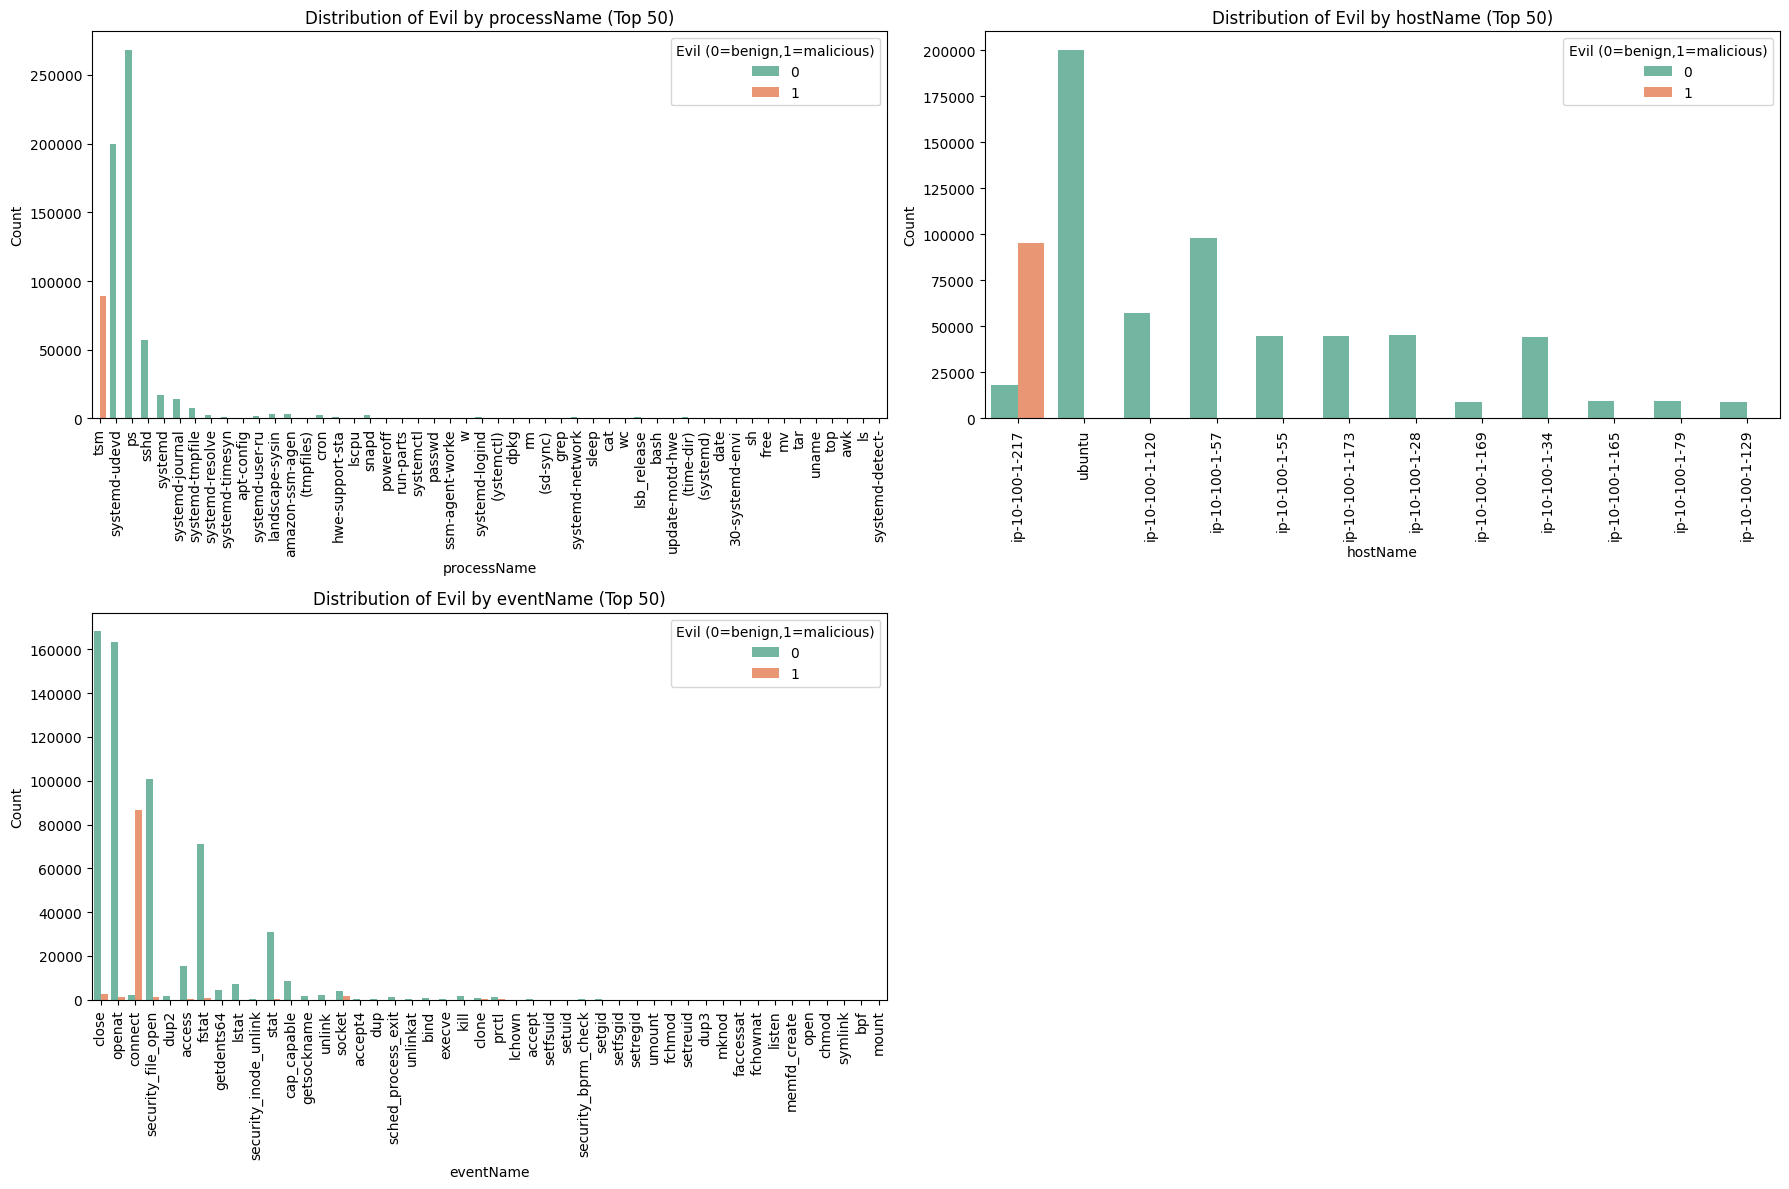

In [3]:

## Grouped Distribution Analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Drop unwanted columns if present
df_beth = df_beth.drop(columns=['args', 'stackAddresses'], errors='ignore')

def plot_evil_distribution_subplots(df, cat_cols, evil_col='evil', top_n=20):
    """
    Plot count of evil (0/1) for top N categories in multiple categorical columns as subplots (2x2).
    """
    num_plots = len(cat_cols)
    rows = 2
    cols = 2
    fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        # Select top N categories
        top_values = df[col].value_counts().head(top_n).index
        df_top = df[df[col].isin(top_values)]

        sns.countplot(
            data=df_top,
            x=col,
            hue=evil_col,
            palette='Set2',
            ax=axes[i]
        )
        axes[i].set_title(f"Distribution of Evil by {col} (Top {top_n})")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis='x', rotation=90)
        axes[i].legend(title="Evil (0=benign,1=malicious)")

    # Hide any unused subplots if fewer than 4 columns
    for j in range(i + 1, rows * cols):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Get categorical columns
categorical_cols = df_beth.select_dtypes(include='object').columns.tolist()

# Plot first 4 categorical columns as 2x2 subplots
plot_evil_distribution_subplots(df_beth, categorical_cols[:4], evil_col='evil', top_n=50)


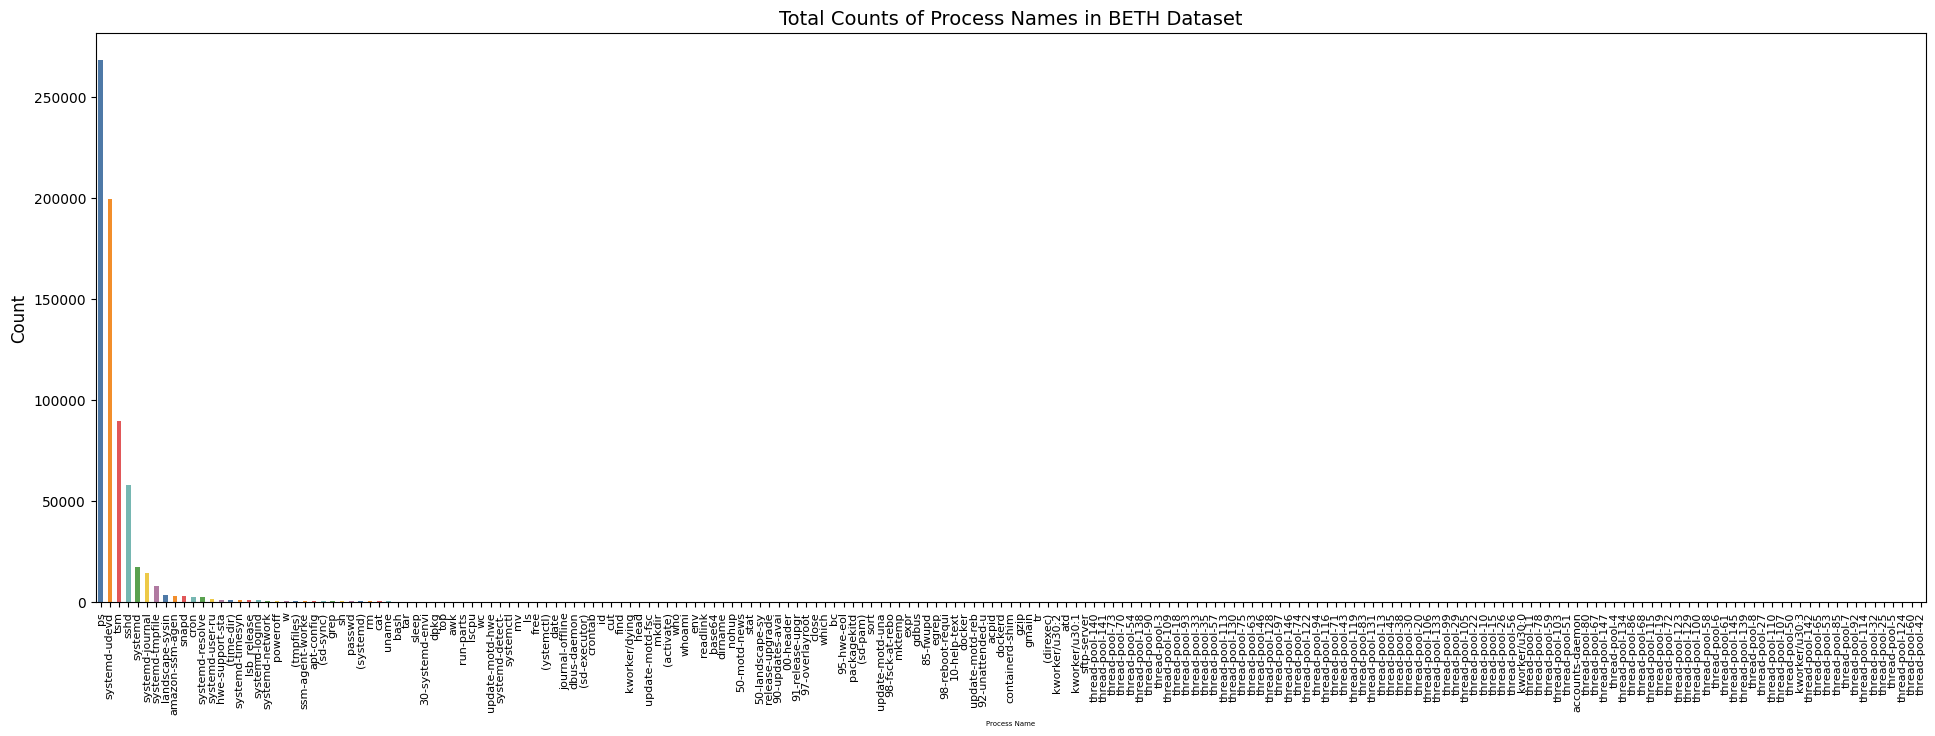

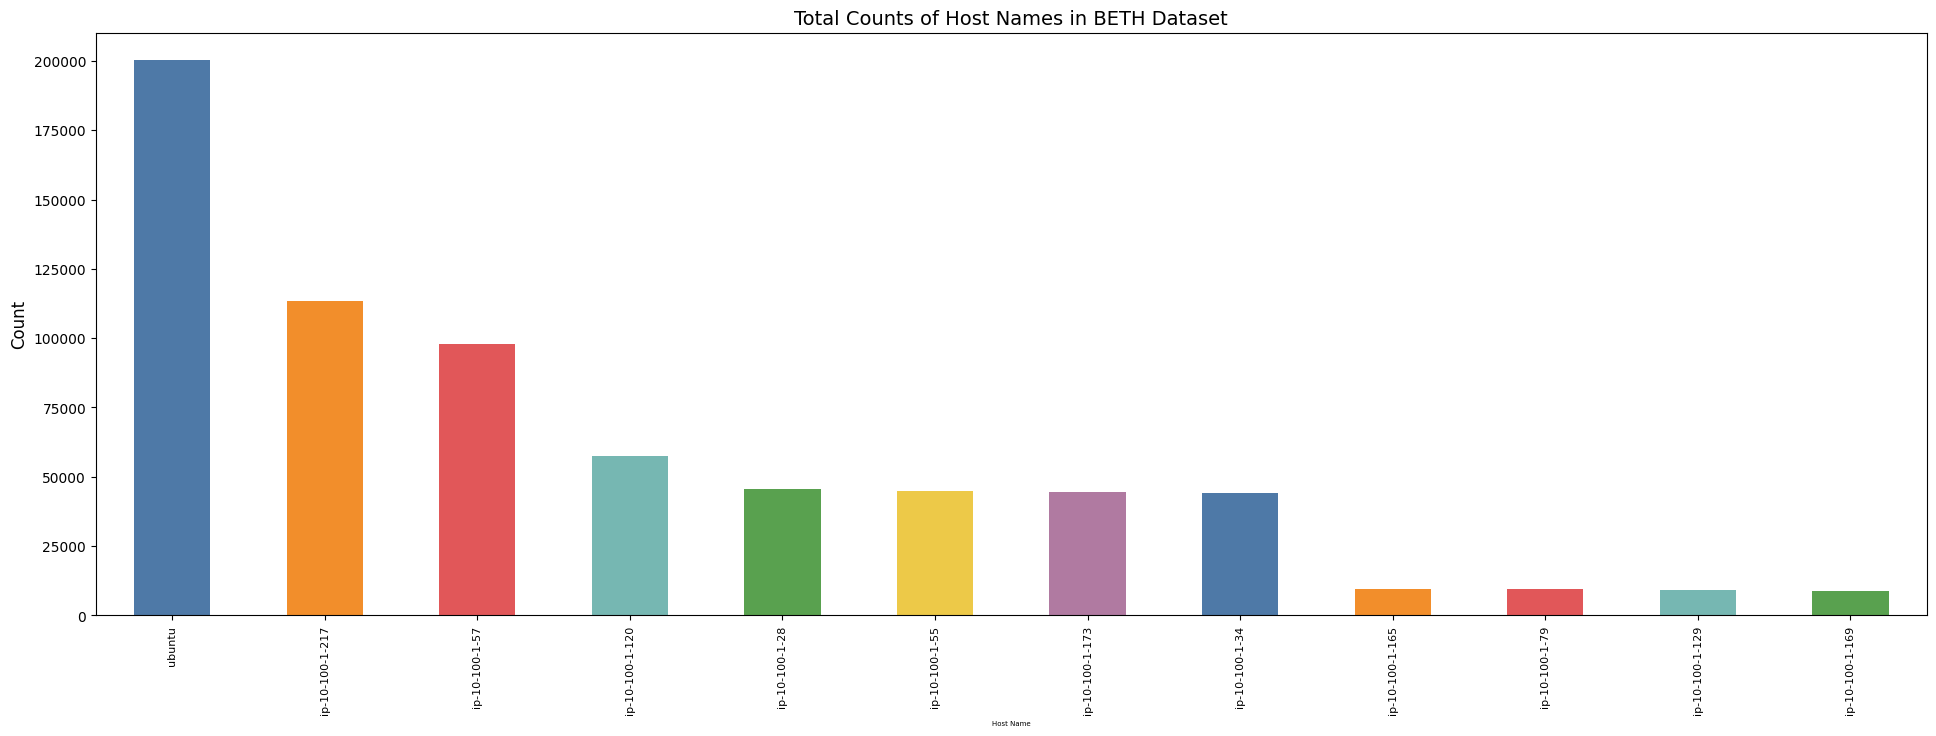

In [4]:
## Categorical Count Analysis
counts = df_beth["processName"].value_counts()
#print(counts)

# Create bar plot with improved layout
plt.figure(figsize=(20, 8))
counts.plot(kind="bar", color=["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f", "#edc948", "#b07aa1"][:len(counts)])
plt.xlabel("Process Name", fontsize=5)
plt.ylabel("Count", fontsize=12)
plt.title("Total Counts of Process Names in BETH Dataset", fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.margins(x=0.02)
plt.tight_layout(pad=3.0)
plt.show()

counts = df_beth["hostName"].value_counts()
#print(counts)

# Create bar plot with improved layout
plt.figure(figsize=(20, 8))
counts.plot(kind="bar", color=["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f", "#edc948", "#b07aa1"][:len(counts)])
plt.xlabel("Host Name", fontsize=5)
plt.ylabel("Count", fontsize=12)
plt.title("Total Counts of Host Names in BETH Dataset", fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.margins(x=0.02)
plt.tight_layout(pad=3.0)
plt.show()


In [5]:
 
## Summary Statistics
numeric_columns_beth = df_beth.select_dtypes(include=['number']).columns.tolist()
categorical_columns_beth = df_beth.select_dtypes(include=['object']).columns.tolist()

summary_bethlist = []

# Numeric columns: mean, median, mode
for col in numeric_columns_beth:
    mean_val = df_beth[col].mean()
    median_val = df_beth[col].median()
    mode_val = df_beth[col].mode().values[0] if not df_beth[col].mode().empty else None
    summary_bethlist.append({
        'Column': col,
        'Type': 'Numeric',
        'Mean': round(mean_val, 2),
        'Median': round(median_val, 2),
        'Mode': mode_val
    })

# Categorical columns: mode only (mean & median are None)
for col in categorical_columns_beth:
    mode_val = df_beth[col].mode().values[0] if not df_beth[col].mode().empty else None
    summary_bethlist.append({
        'Column': col,
        'Type': 'Categorical',
        'Mean': None,
        'Median': None,
        'Mode': mode_val
    })

# Create DataFrame
summary_df_beth = pd.DataFrame(summary_bethlist)

summary_df_beth


,Column,Type,Mean,Median,Mode
0,timestamp,Numeric,1.367750e+03,9.033600e+02,132.934905
1,processId,Numeric,6.907280e+03,7.366000e+03,7555
2,threadId,Numeric,6.911380e+03,7.366000e+03,7555
3,parentProcessId,Numeric,2.468980e+03,1.385000e+03,187
4,userId,Numeric,1.438100e+02,0.000000e+00,0
5,mountNamespace,Numeric,4.026532e+09,4.026532e+09,4026531840
6,eventId,Numeric,2.370800e+02,4.200000e+01,3
7,argsNum,Numeric,2.670000e+00,3.000000e+00,4
8,returnValue,Numeric,2.970000e+00,0.000000e+00,0
9,sus,Numeric,1.500000e-01,0.000000e+00,0


In [22]:
## Minimum and Maximum Value Review
min_max_beth = pd.DataFrame({
    "Minimum": df_beth[numeric_columns_beth].min(),
    "Maximum": df_beth[numeric_columns_beth].max()
})

min_max_beth

,Minimum,Maximum
timestamp,1.244398e+02,3.954588e+03
processId,1.000000e+00,8.619000e+03
threadId,1.000000e+00,8.619000e+03
parentProcessId,0.000000e+00,7.672000e+03
userId,0.000000e+00,1.001000e+03
mountNamespace,4.026532e+09,4.026532e+09
eventId,2.000000e+00,1.010000e+03
argsNum,0.000000e+00,5.000000e+00
returnValue,-1.150000e+02,3.276800e+04
sus,0.000000e+00,1.000000e+00


In [6]:
import pandas as pd
## Outlier Review
Q1 = df_beth[numeric_columns_beth].quantile(0.25)
Q3 = df_beth[numeric_columns_beth].quantile(0.75)
IQR = Q3 - Q1

# Detect outliers
outlier_mask = ((df_beth[numeric_columns_beth] < (Q1 - 1.5 * IQR)) | (df_beth[numeric_columns_beth] > (Q3 + 1.5 * IQR)))

# Find columns that have any outliers
cols_with_outliers = outlier_mask.any()
cols_outlier_list = cols_with_outliers[cols_with_outliers].index.tolist()

# Create DataFrame to show columns with outliers
outliers_df_beth = pd.DataFrame({'Columns With Outliers': cols_outlier_list})

outliers_df_beth


,Columns With Outliers
0,processId
1,threadId
2,userId
3,eventId
4,returnValue
5,sus
6,evil


### BETH Dataset Conclusion

The BETH dataset is useful for host-level cybersecurity analysis because it contains process, user, host, event, suspicious-label, and malicious-label features.

The univariate plots show that several numeric features are not normally distributed. Features such as process ID, thread ID, user ID, event ID, and return value show clustered, skewed, or multimodal patterns. These patterns are expected in system-log data and may contain useful signals for identifying abnormal activity.

The grouped plots using the `evil` label show how malicious activity is distributed across selected process, host, and event features. These visualizations help identify which host-level features may be useful for later classification and anomaly detection.

The `sus` and `evil` labels show class imbalance, so later model evaluation should not rely only on accuracy. Recall, F1-score, ROC-AUC, and confusion matrices are more appropriate for evaluating threat detection models.

Overall, BETH is one of the stronger datasets in this project for host-level behavior analysis, but its skewed distributions and class imbalance require careful preprocessing and evaluation.

### 2. Cybersecurity Attacks Dataset

The Cybersecurity Attacks dataset contains network-security event records with packet-level features, anomaly scores, attack types, severity levels, and action-related fields.

The univariate analysis focuses on packet length, anomaly score distribution, attack-type counts, severity-level counts, and how anomaly scores vary across categorical security features.

In [7]:

## https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks

CSA_dataset_path = kagglehub.dataset_download("teamincribo/cyber-security-attacks")
print("Path to dataset files:", CSA_dataset_path)
import os

# List all files in the dataset directory
print(os.listdir(CSA_dataset_path))
csa_csv_path = os.path.join(CSA_dataset_path, "cybersecurity_attacks.csv")
df_csa = pd.read_csv(csa_csv_path)


100%|██████████| 5.03M/5.03M [00:00<00:00, 16.1MB/s]

Extracting files...


Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\teamincribo\cyber-security-attacks\versions\32
['cybersecurity_attacks.csv', 'README.md']


In [8]:

cols_to_dropcsa = ['Timestamp','Payload Data', 'Source Port', 'Destination Port', 'IDS/IPS Alerts', 'Source IP Address','Destination IP Address','User Information', 'Device Information','Geo-location Data', 'Firewall Logs', 'Proxy Information','Log Source']
df_new_csa = df_csa.drop(columns=cols_to_dropcsa)
df_new_csa["Malware Indicators"] = df_new_csa["Malware Indicators"].fillna("None Detected")
df_new_csa["Alerts/Warnings"] = df_new_csa["Alerts/Warnings"].fillna("No Alert")


csa_numeric_columns=df_new_csa.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(csa_numeric_columns.to_list())
print('\n')

csa_categorical_columns=df_new_csa.select_dtypes(include='object').columns
print("Categorical columns in the dataset:\n")
print(csa_categorical_columns.to_list())

Numeric columns in the dataset:

['Packet Length', 'Anomaly Scores']


Categorical columns in the dataset:

['Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'Network Segment']


Plotting univariate analysis for: Packet Length


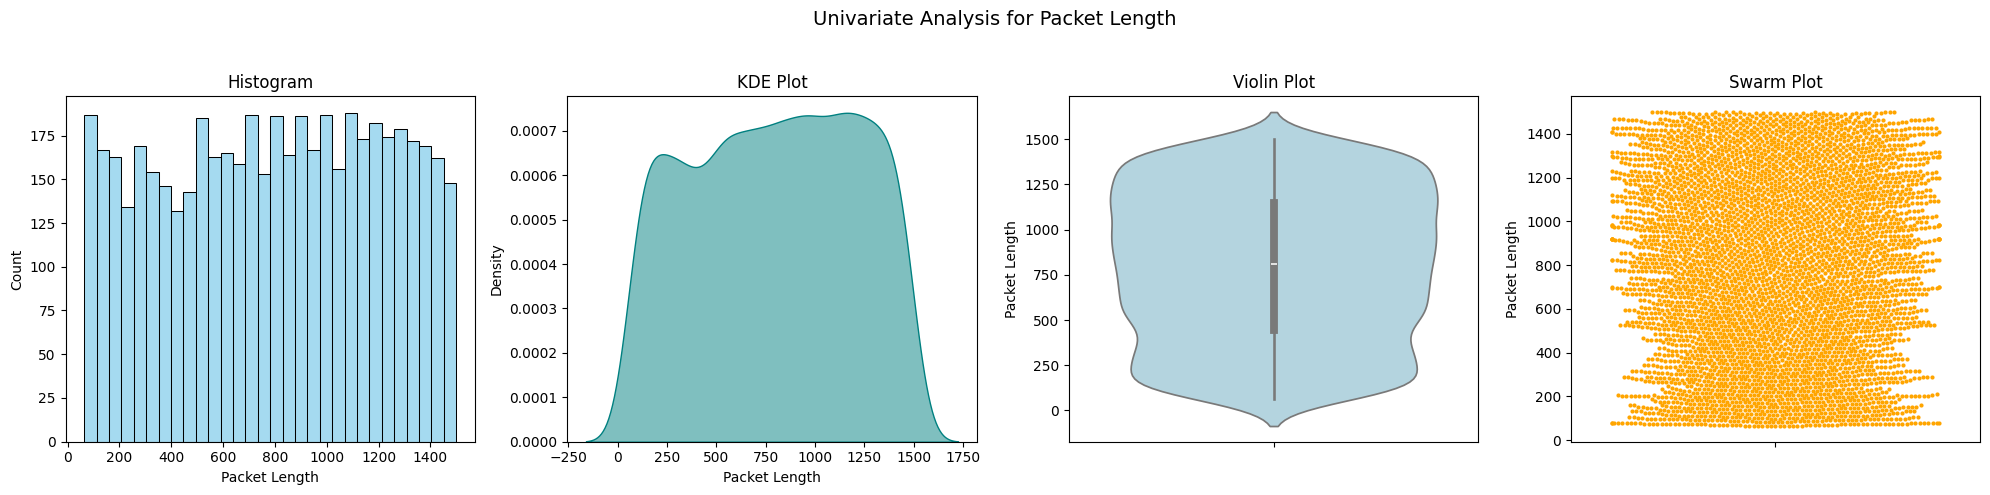

Plotting univariate analysis for: Anomaly Scores


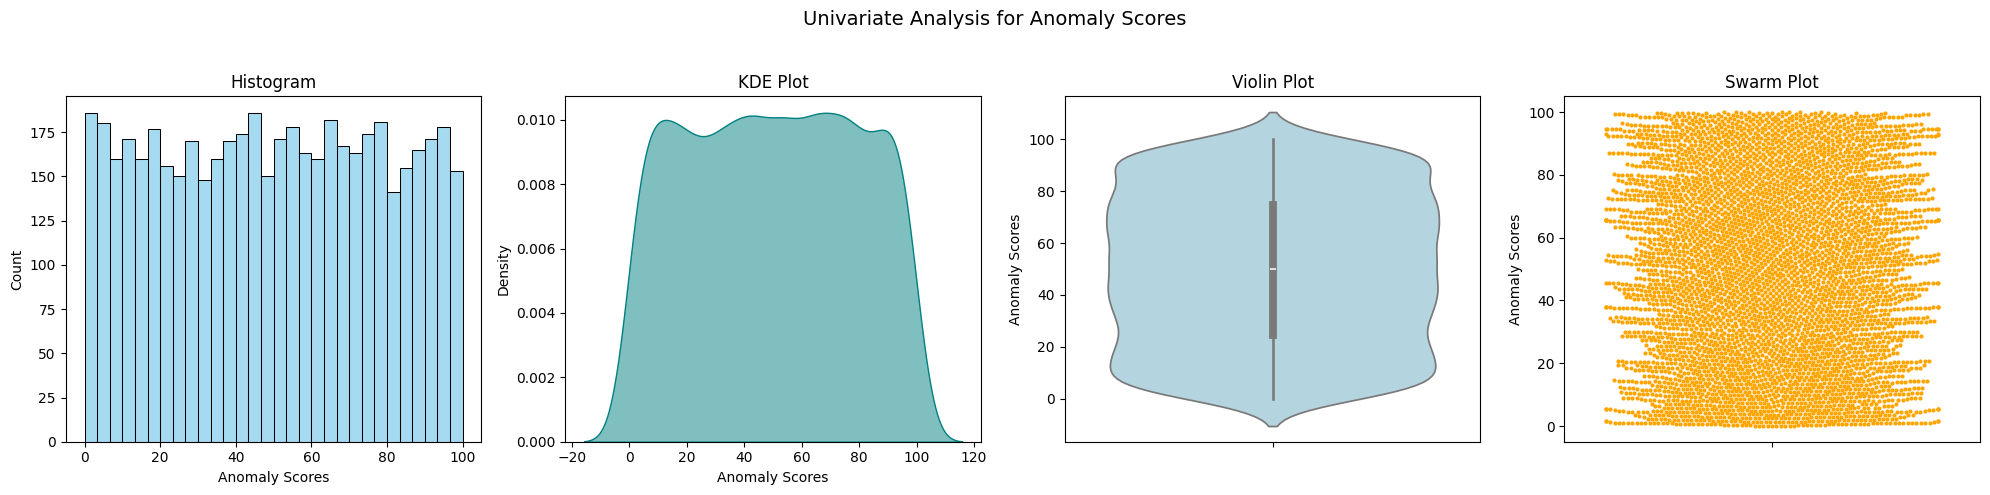

In [9]:
## Numeric Feature Distribution Analysis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Define numeric columns for univariate analysis
numeric_columns = ['Packet Length', 'Anomaly Scores']

# Sample if dataset is large
df_sample = df_new_csa.sample(n=min(5000, len(df_new_csa)), random_state=42)

# Plotting
for col in numeric_columns:
    print(f"Plotting univariate analysis for: {col}")
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"Univariate Analysis for {col}", fontsize=14)

    # Histogram
    sns.histplot(data=df_sample, x=col, bins=30, color='skyblue', kde=False, ax=axes[0])
    axes[0].set_title("Histogram")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    # KDE Plot
    sns.kdeplot(data=df_sample, x=col, fill=True, color='teal', alpha=0.5, ax=axes[1])
    axes[1].set_title("KDE Plot")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Density")

    # Violin Plot
    sns.violinplot(data=df_sample, y=col, color='lightblue', ax=axes[2])
    axes[2].set_title("Violin Plot")
    axes[2].set_ylabel(col)

    # Swarm Plot
    sns.swarmplot(data=df_sample, y=col, color='orange', size=3, ax=axes[3])
    axes[3].set_title("Swarm Plot")
    axes[3].set_ylabel(col)

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to accommodate suptitle
    plt.show()


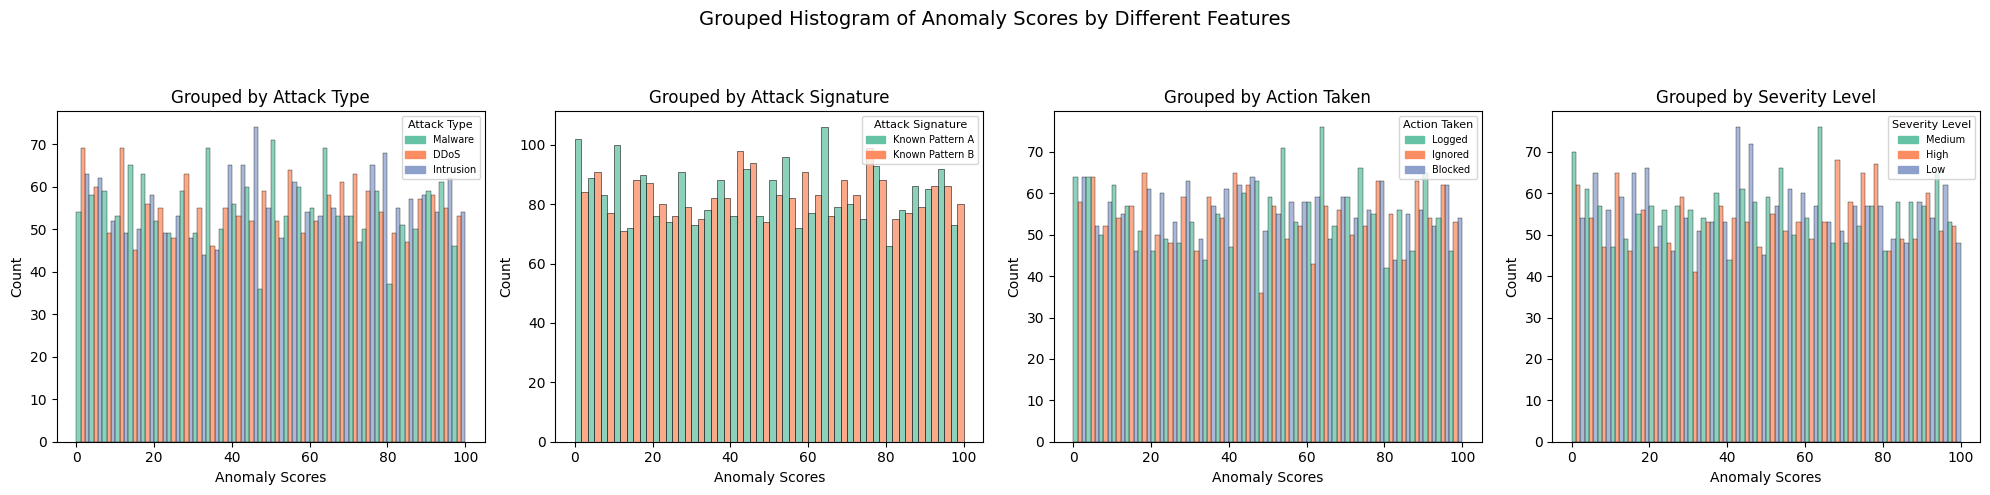

In [10]:

## Grouped Distribution Analysis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch  # <-- Manual legend patch

# Sample numeric and categorical columns
numeric_columns = ['Anomaly Scores']
categorical_columns = ['Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level']

# Sample the dataset
df_sample = df_new_csa.sample(n=min(5000, len(df_new_csa)), random_state=42)

# Plot all grouped histograms in one row per numeric column
for num_col in numeric_columns:
    fig, axes = plt.subplots(1, len(categorical_columns), figsize=(5 * len(categorical_columns), 5))
    fig.suptitle(f"Grouped Histogram of {num_col} by Different Features", fontsize=14)

    for i, cat_col in enumerate(categorical_columns):
        ax = axes[i]
        
        # Get unique categories and assign consistent colors
        categories = df_sample[cat_col].dropna().unique()
        palette = sns.color_palette('Set2', n_colors=len(categories))
        color_dict = dict(zip(categories, palette))

        # Plot using that palette
        sns.histplot(
            data=df_sample,
            x=num_col,
            hue=cat_col,
            multiple='dodge',
            palette=color_dict,
            bins=30,
            stat='count',
            common_norm=False,
            ax=ax
        )
        ax.set_title(f"Grouped by {cat_col}")
        ax.set_xlabel(num_col)
        ax.set_ylabel("Count")

        # Manually build legend with color patches
        legend_patches = [Patch(color=color_dict[val], label=val) for val in categories]
        ax.legend(handles=legend_patches, title=cat_col, fontsize=7, title_fontsize=8, loc='best')

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


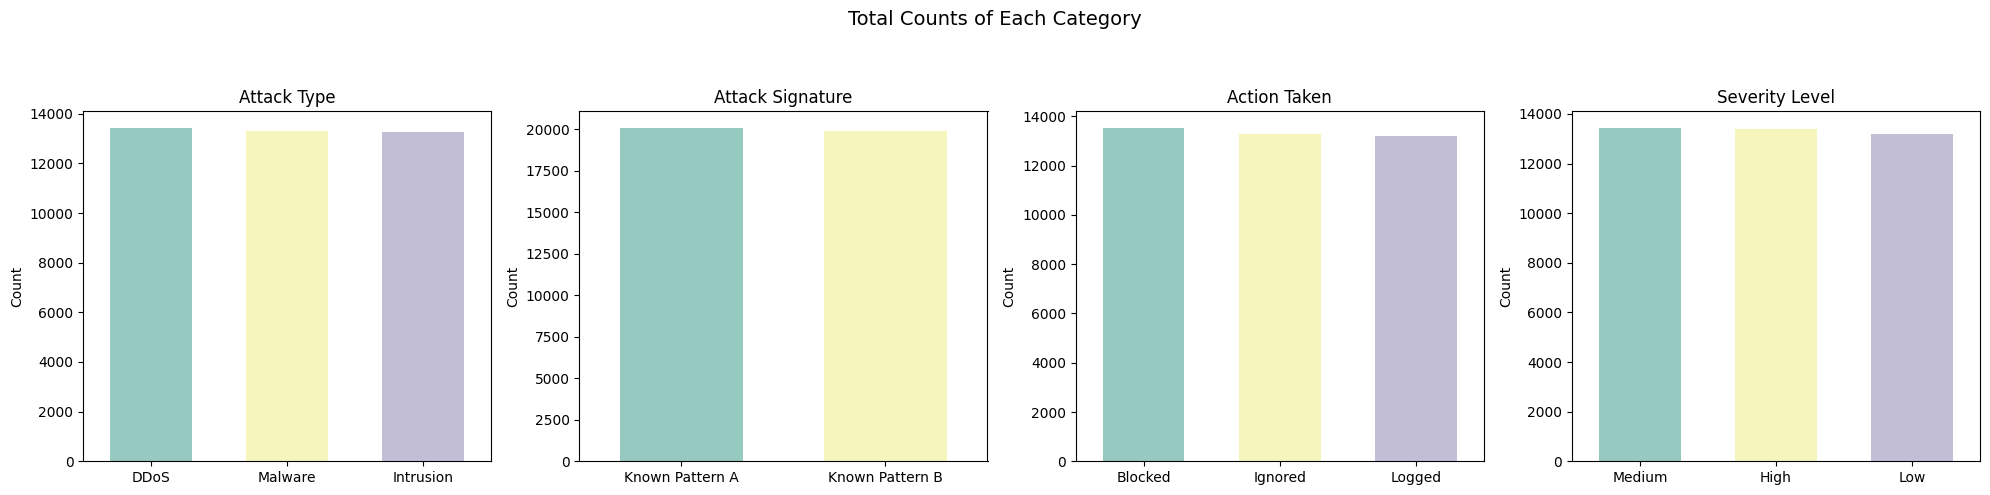

In [11]:
## Categorical Count Analysis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Categorical columns to plot
categorical_columns = [
    'Attack Type', 'Attack Signature',
    'Action Taken', 'Severity Level'
]

# Create a row of subplots
fig, axes = plt.subplots(1, len(categorical_columns), figsize=(5 * len(categorical_columns), 5))
fig.suptitle("Total Counts of Each Category", fontsize=14)

# Loop through columns and assign to each subplot
for i, col in enumerate(categorical_columns):
    sns.countplot(
        data=df_new_csa,
        x=col,
        order=df_new_csa[col].value_counts().index,
        palette="Set3",
        width=0.6,
        ax=axes[i]
    )
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', labelrotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


In [12]:
## Summary Statistics
import pandas as pd

# Define columns
numeric_columns = ['Packet Length', 'Anomaly Scores']
categorical_columns = [
    'Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators',
    'Alerts/Warnings', 'Attack Type', 'Attack Signature',
    'Action Taken', 'Severity Level', 'Network Segment'
]

# Create list to collect rows
summary_data = []

# Numeric columns: mean, median, mode
for col in numeric_columns:
    mean_val = df_new_csa[col].mean()
    median_val = df_new_csa[col].median()
    mode_val = df_new_csa[col].mode().values[0] if not df_new_csa[col].mode().empty else None
    summary_data.append({
        'Column': col,
        'Type': 'Numeric',
        'Mean': round(mean_val, 2),
        'Median': round(median_val, 2),
        'Mode': mode_val
    })

# Categorical columns: only mode
for col in categorical_columns:
    mode_val = df_new_csa[col].mode().values[0] if not df_new_csa[col].mode().empty else None
    summary_data.append({
        'Column': col,
        'Type': 'Categorical',
        'Mean': None,
        'Median': None,
        'Mode': mode_val
    })

# Create DataFrame
summary_df_csa = pd.DataFrame(summary_data)

# Display the summary
summary_df_csa


,Column,Type,Mean,Median,Mode
0,Packet Length,Numeric,781.45,782.00,1037
1,Anomaly Scores,Numeric,50.11,50.34,15.39
2,Protocol,Categorical,NaN,NaN,ICMP
3,Packet Type,Categorical,NaN,NaN,Control
4,Traffic Type,Categorical,NaN,NaN,DNS
5,Malware Indicators,Categorical,NaN,NaN,IoC Detected
6,Alerts/Warnings,Categorical,NaN,NaN,No Alert
7,Attack Type,Categorical,NaN,NaN,DDoS
8,Attack Signature,Categorical,NaN,NaN,Known Pattern A
9,Action Taken,Categorical,NaN,NaN,Blocked


In [24]:
## Minimum and Maximum Value Review

csa_numeric_columns = df_new_csa.select_dtypes(include="number").columns

min_max_csa = pd.DataFrame({
    "Minimum": df_new_csa[csa_numeric_columns].min(),
    "Maximum": df_new_csa[csa_numeric_columns].max()
})

min_max_csa

,Minimum,Maximum
Packet Length,64.0,1500.0
Anomaly Scores,0.0,100.0


In [25]:
numeric_columns = ['Packet Length', 'Anomaly Scores']
categorical_columns = [
    'Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators',
    'Alerts/Warnings', 'Attack Type', 'Attack Signature',
    'Action Taken', 'Severity Level', 'Network Segment'
]

# Detect outliers using IQR method for numeric columns in df_beth
Q1 = df_new_csa[numeric_columns].quantile(0.25)
Q3 = df_new_csa[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

# Find columns with any outliers
outliers = ((df_new_csa[numeric_columns] < (Q1 - 1.5 * IQR)) | (df_new_csa[numeric_columns] > (Q3 + 1.5 * IQR))).any()

print("\nColumns with Outliers:\n", outliers[outliers].index.tolist())


Columns with Outliers:
 []


### Cybersecurity Attacks Dataset Conclusion

The Cybersecurity Attacks dataset is useful for basic attack-type exploration and pipeline testing, but it should be interpreted carefully.

The univariate plots for `Packet Length` and `Anomaly Scores` help show how traffic size and threat-score patterns are distributed. These features can support early exploration of suspicious traffic behavior, but they should not be treated as complete evidence of real-world attack behavior.

Grouped histograms show how anomaly scores vary across attack type, attack signature, action taken, and severity level. This is useful for understanding whether different categories have different risk-score patterns.

Categorical bar plots help summarize the distribution of attack-related fields such as attack type, attack signature, action taken, and severity level.

This dataset should not be described as “perfectly balanced” or “no outliers” without careful validation. In the broader capstone work, this dataset had important limitations related to synthetic patterns, missing fields, and rare-class detection. Because of that, it is best used as a supplementary dataset rather than the strongest source for final model performance.

### 3. UNSW-NB15 Intrusion Detection Dataset

The UNSW-NB15 dataset contains network-flow records with protocol, service, state, attack category, and binary attack-label information.

The univariate analysis focuses on network-flow distributions, categorical attack patterns, outliers, and feature shapes that may affect intrusion detection modeling.

In [28]:

## https://doi.org/10.34740/KAGGLE/DSV/9350725

path = kagglehub.dataset_download("dhoogla/unswnb15")

# Load the training and testing  set parquet file into DataFrame
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))

In [29]:
## Numeric Feature Distribution Analysis
df_unsw.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [30]:
 

unsw_numeric_columns=df_unsw.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(unsw_numeric_columns.to_list())
print(f"Count of numeric columns: {len(unsw_numeric_columns)}")

print('\n')

unsw_categorical_columns=df_unsw.select_dtypes(include=['object', 'category']).columns
print("Categorical columns in the dataset:\n")
print(unsw_categorical_columns.to_list())
print(f"Count of categorical columns: {len(unsw_categorical_columns)}")
 

Numeric columns in the dataset:

['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'label']
Count of numeric columns: 32


Categorical columns in the dataset:

['proto', 'service', 'state', 'attack_cat']
Count of categorical columns: 4


Plotting for: dur


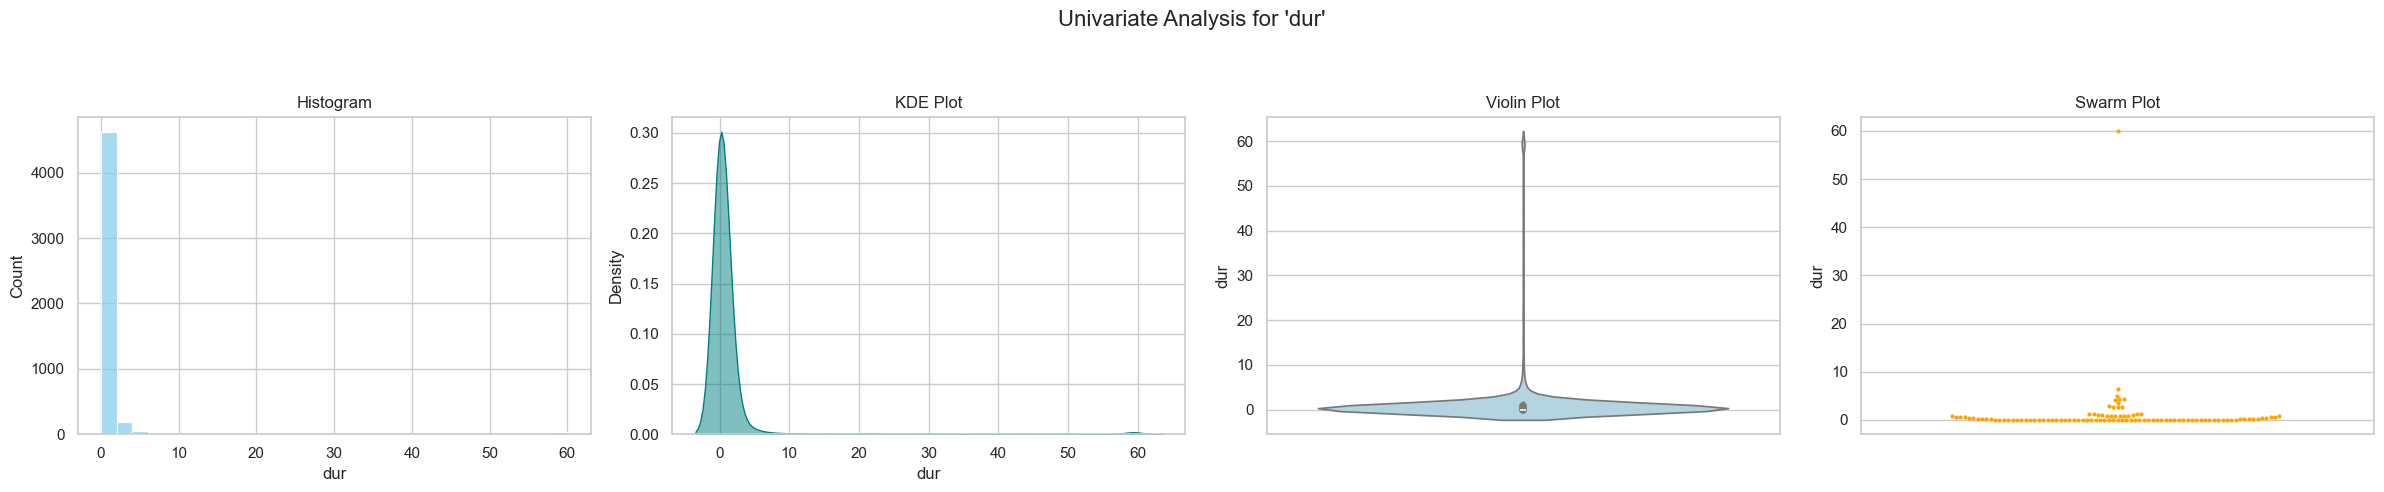

Plotting for: spkts


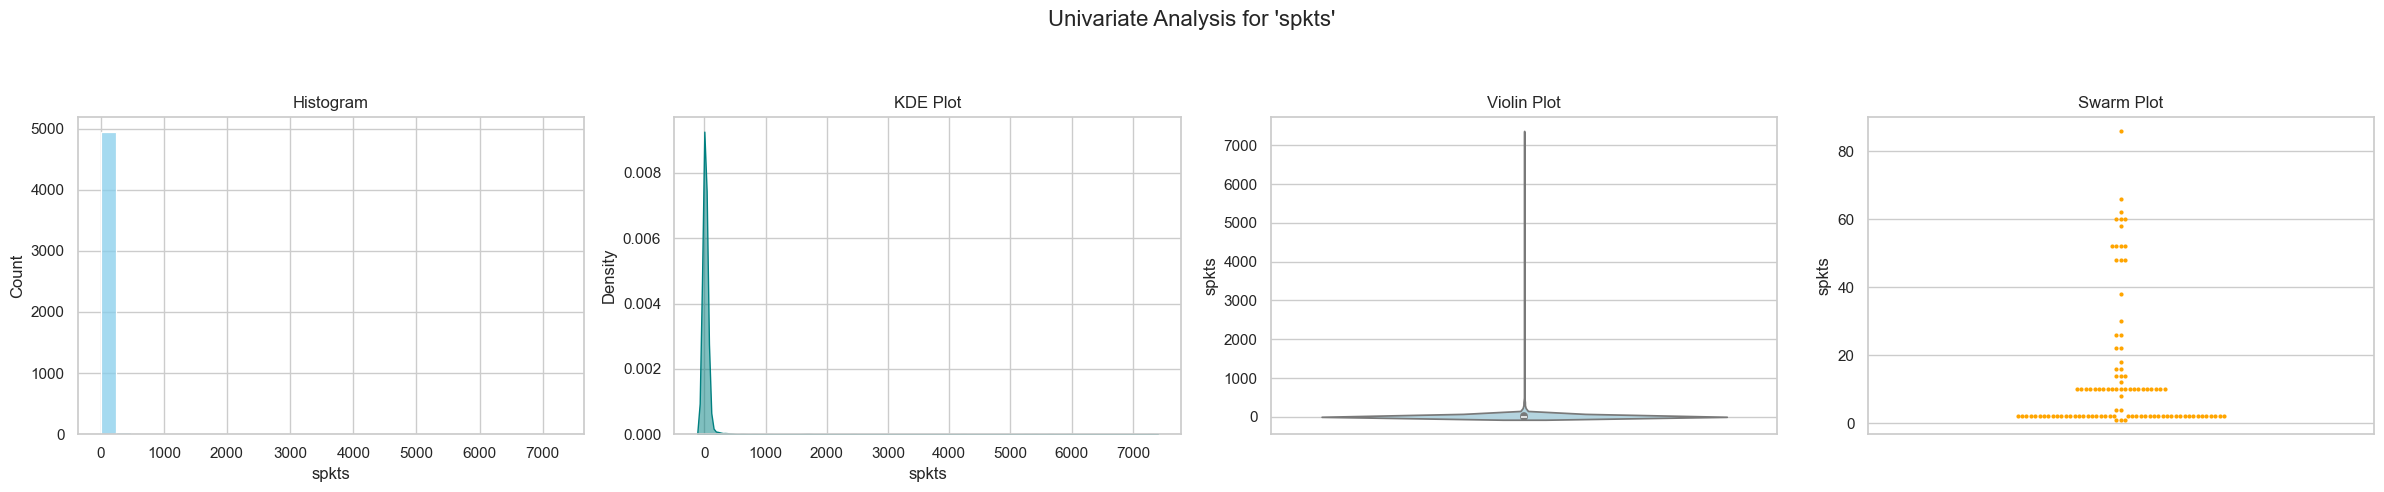

Plotting for: dpkts


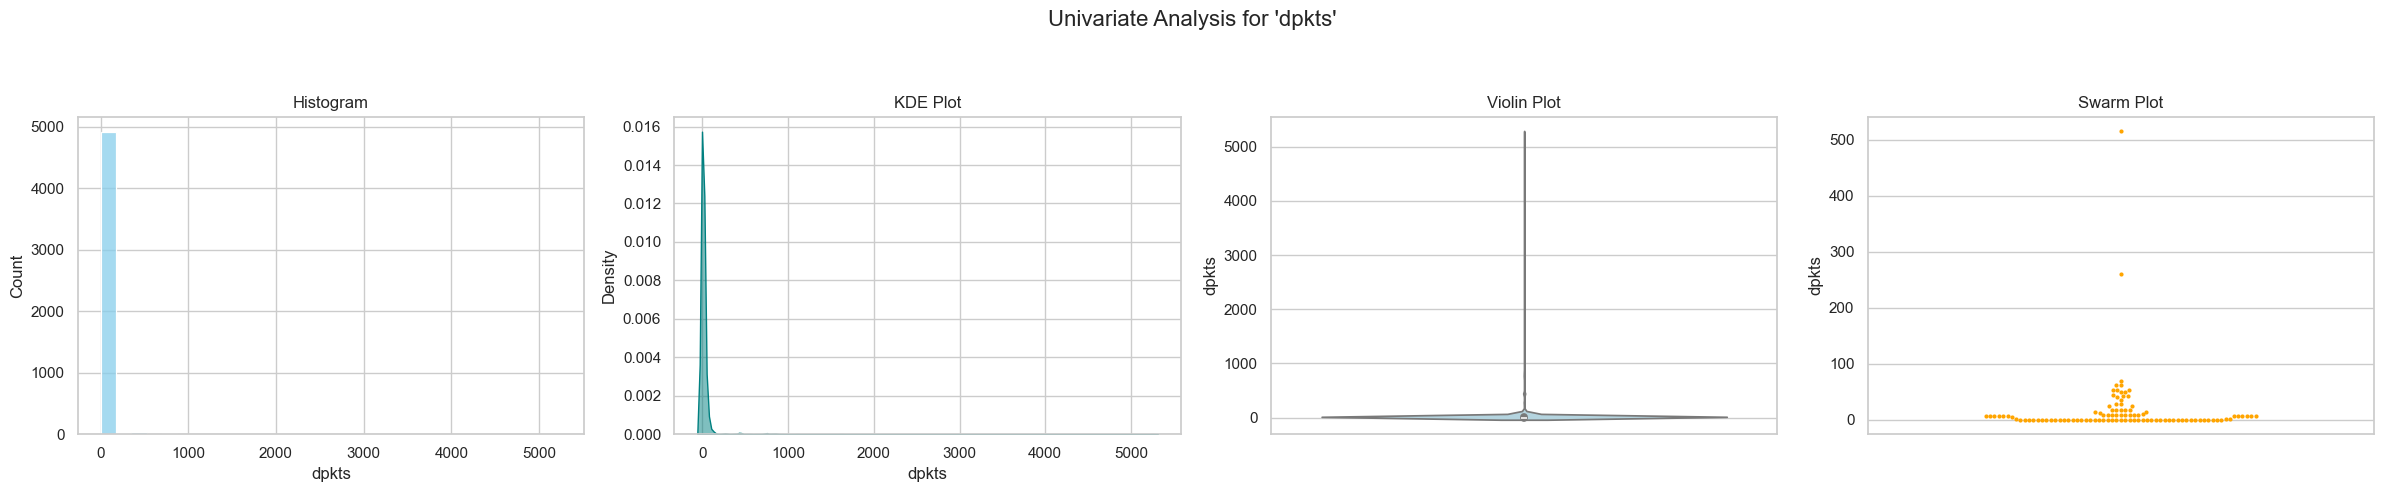

Plotting for: sbytes


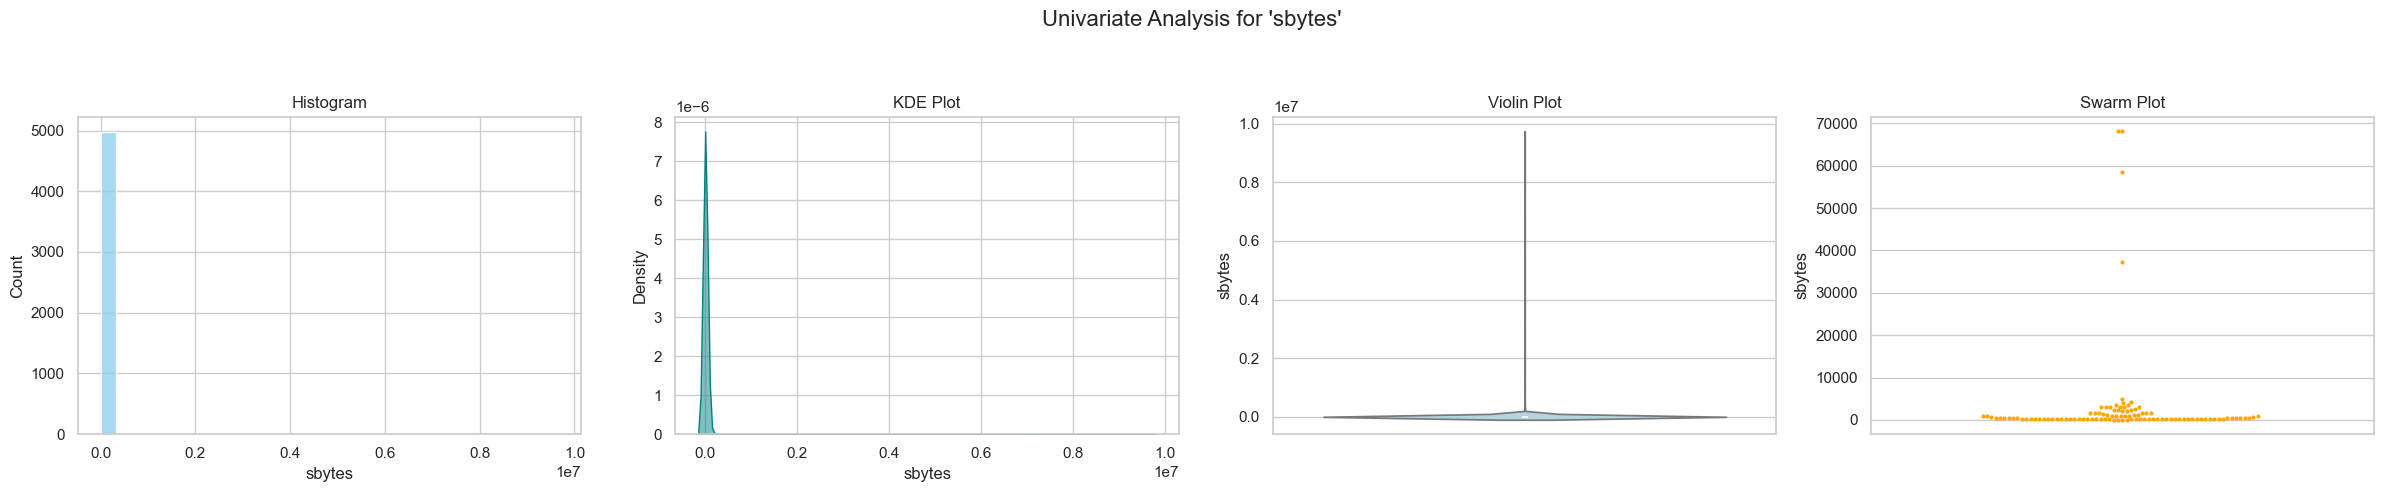

Plotting for: dbytes


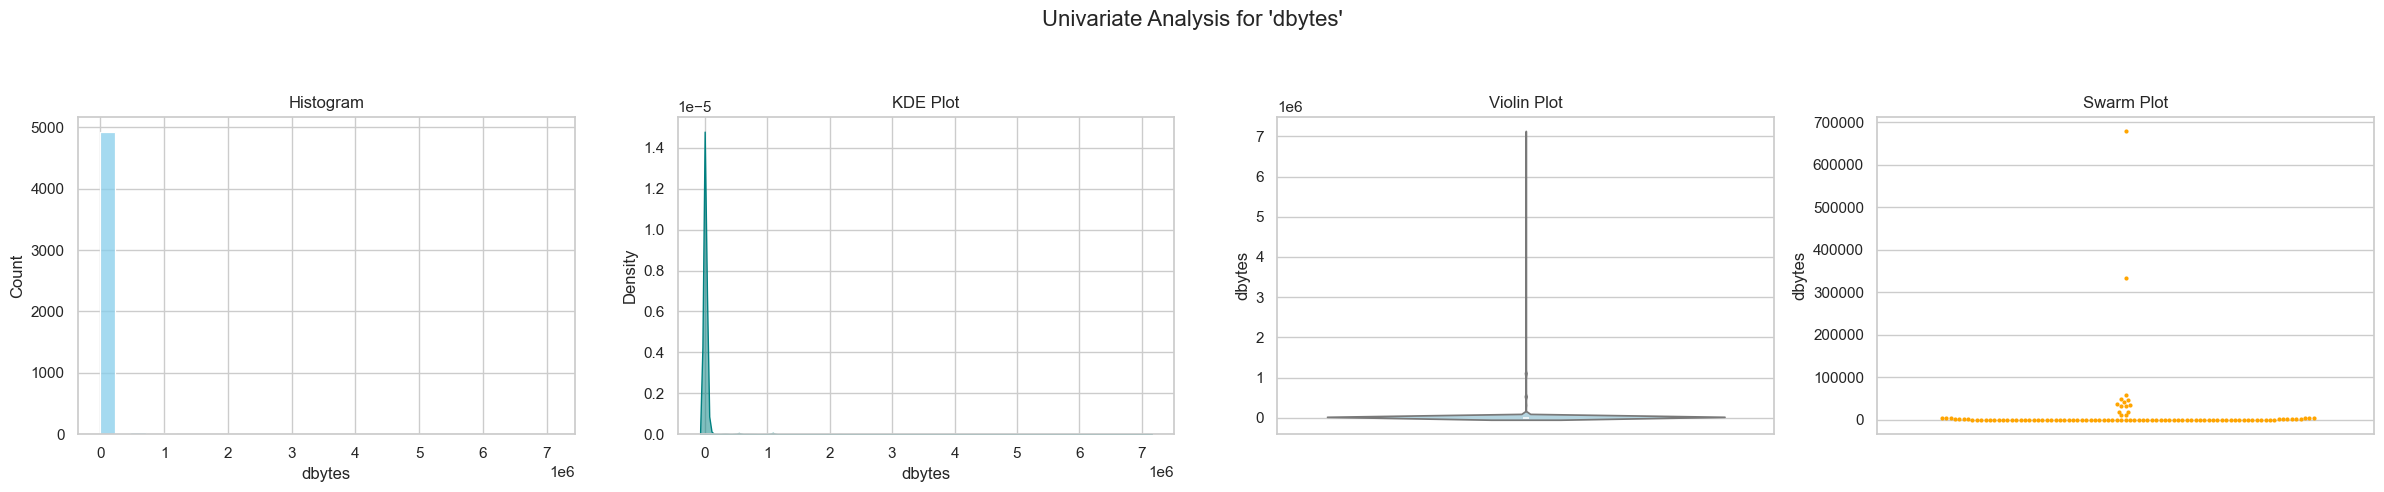

Plotting for: rate


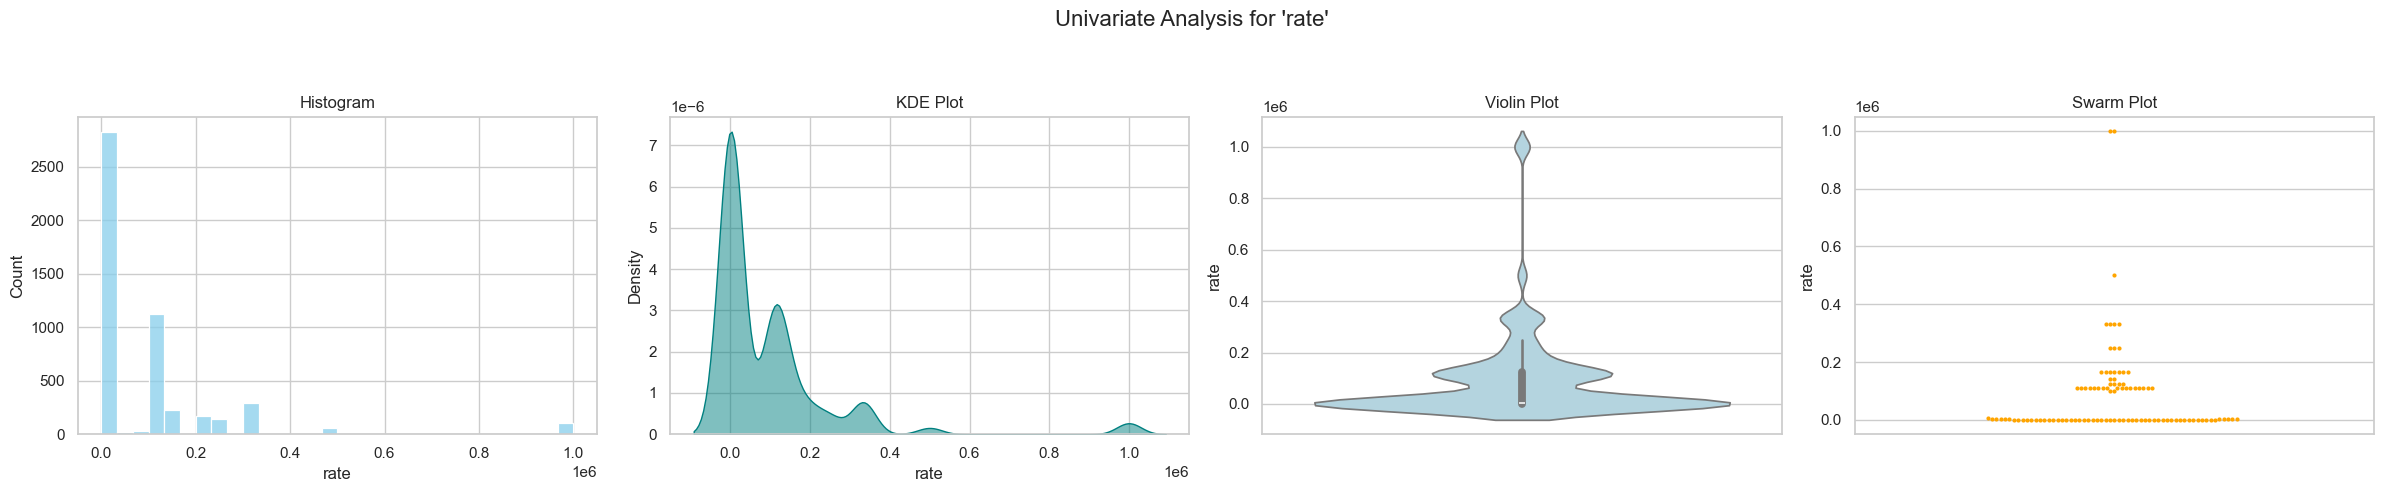

Plotting for: sload


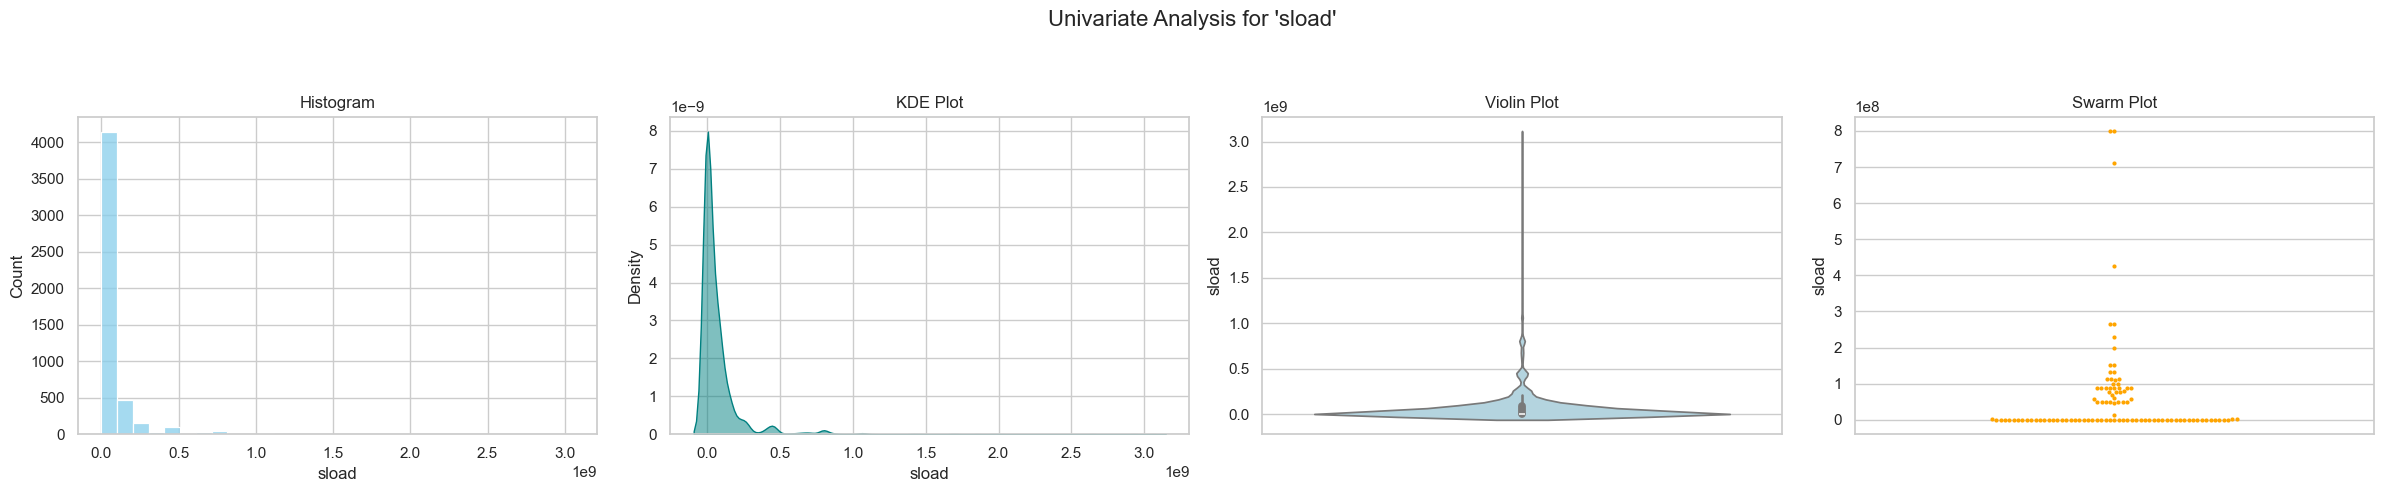

Plotting for: dload


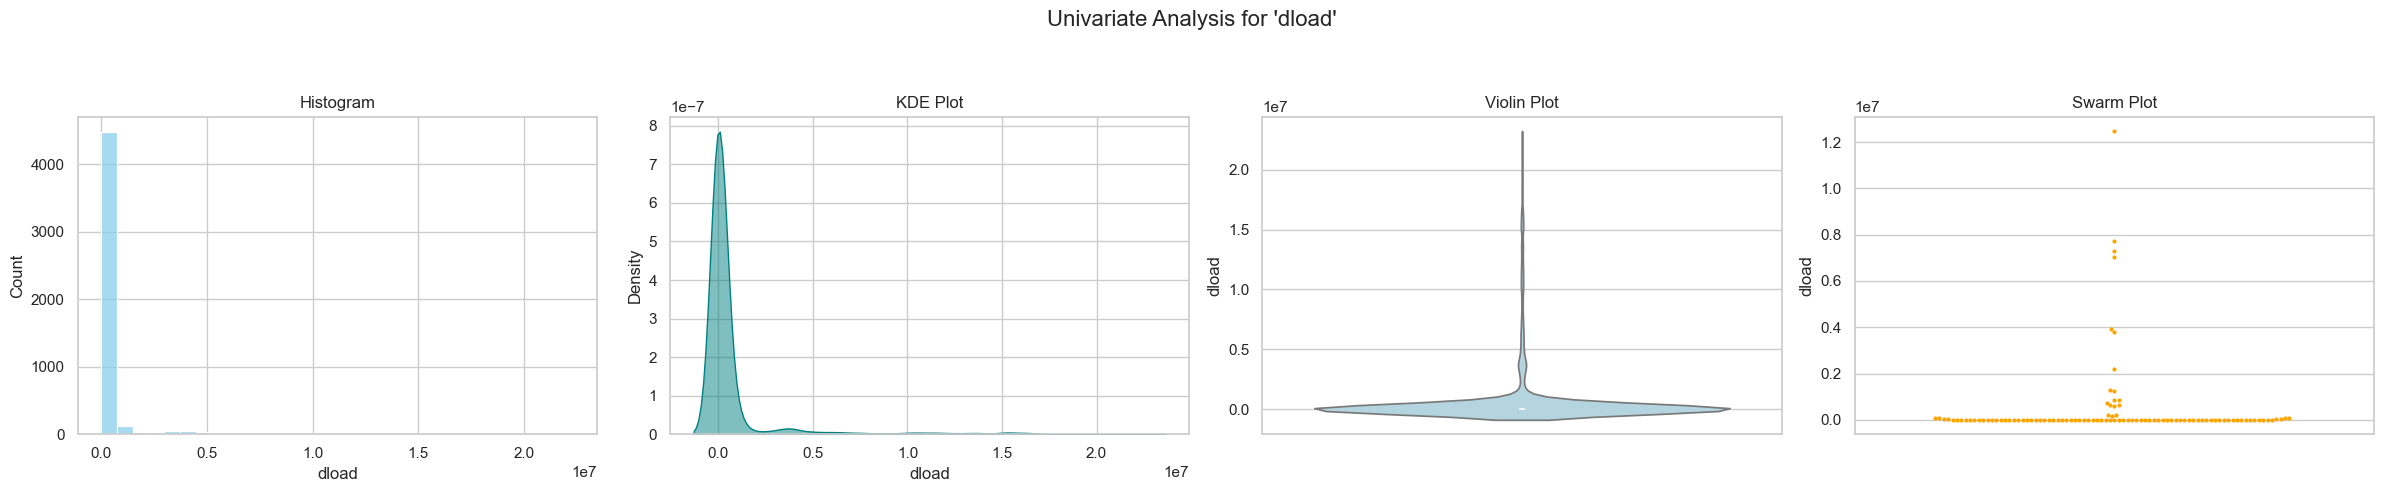

Plotting for: sloss


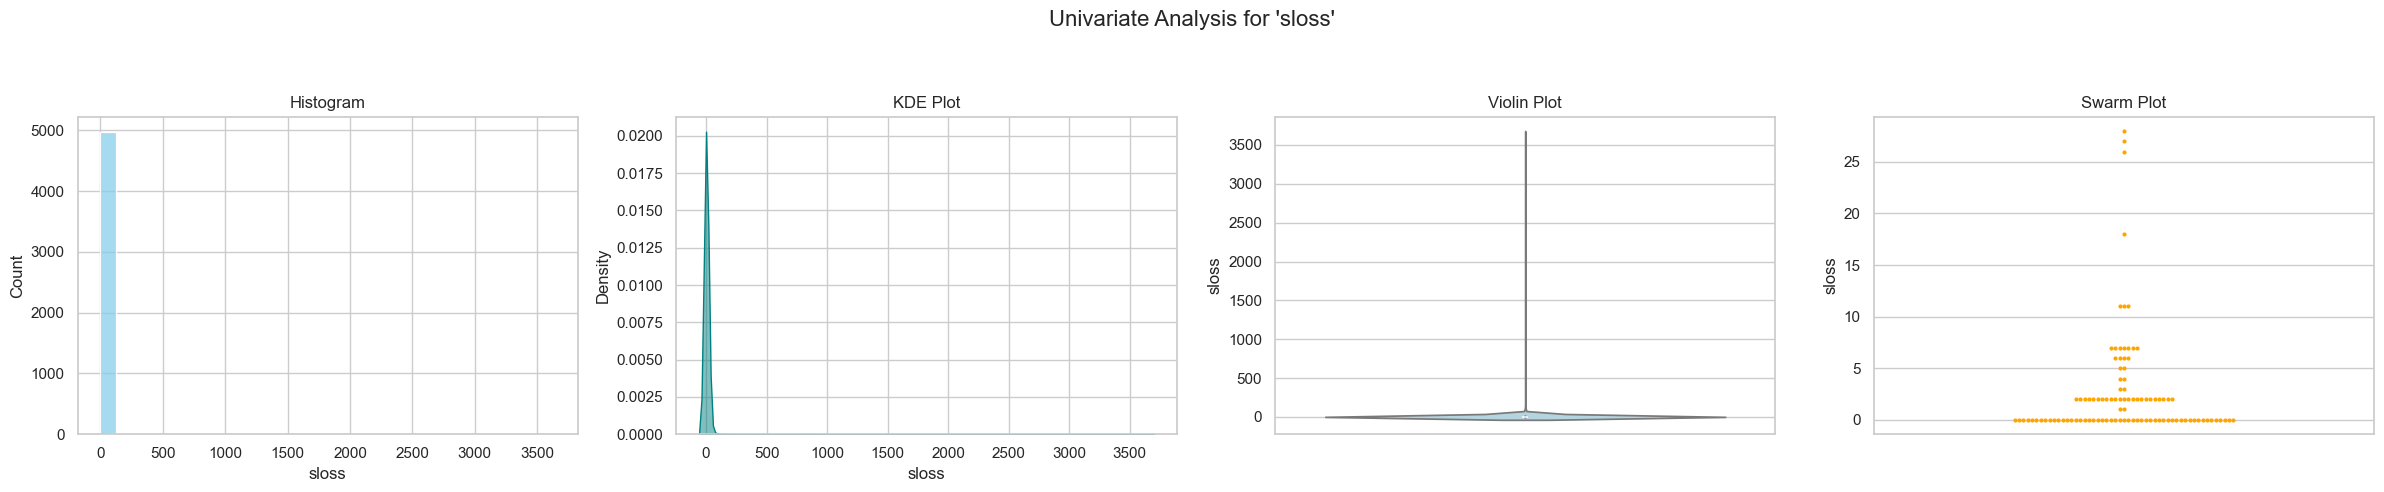

Plotting for: dloss


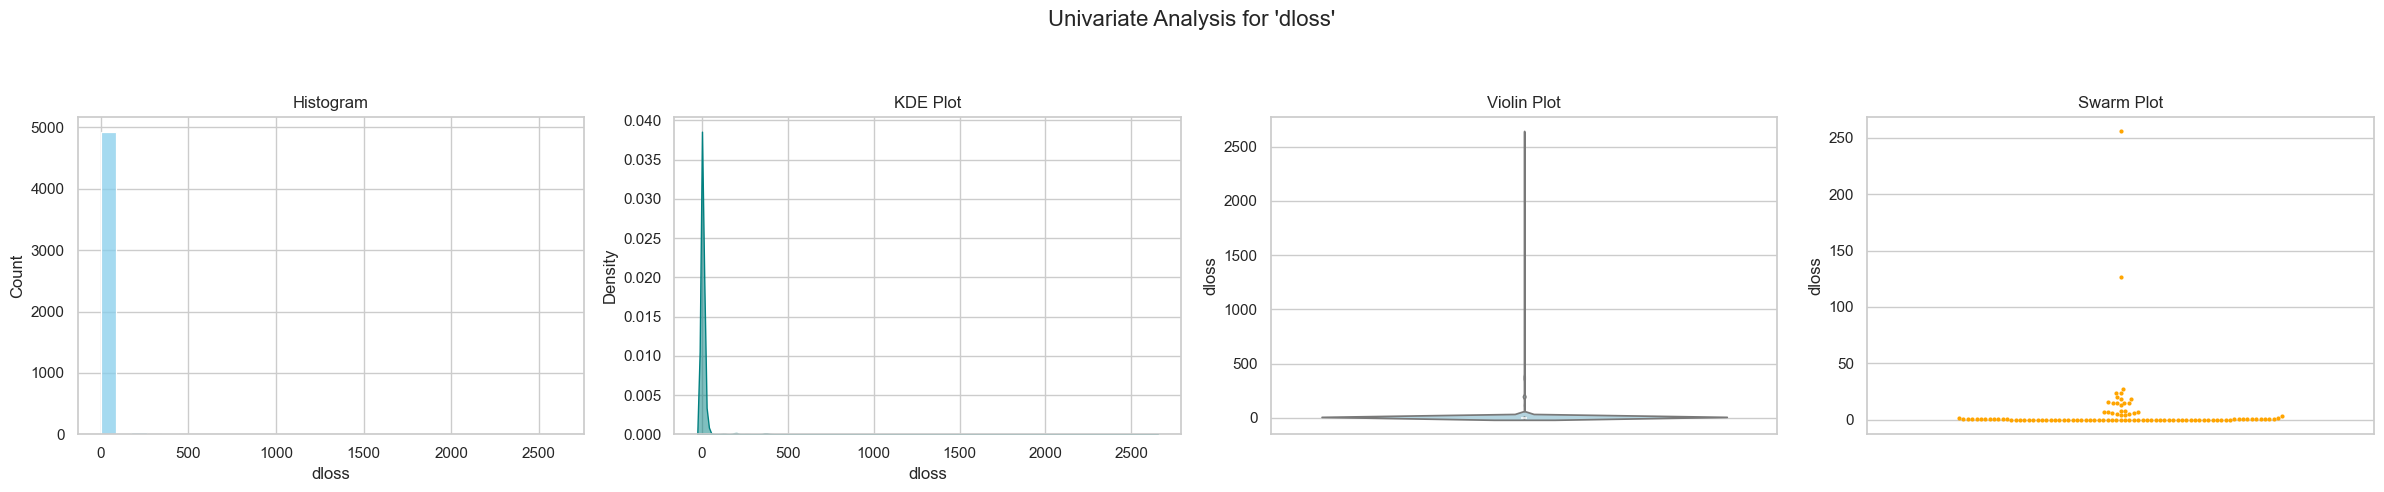

Plotting for: sinpkt


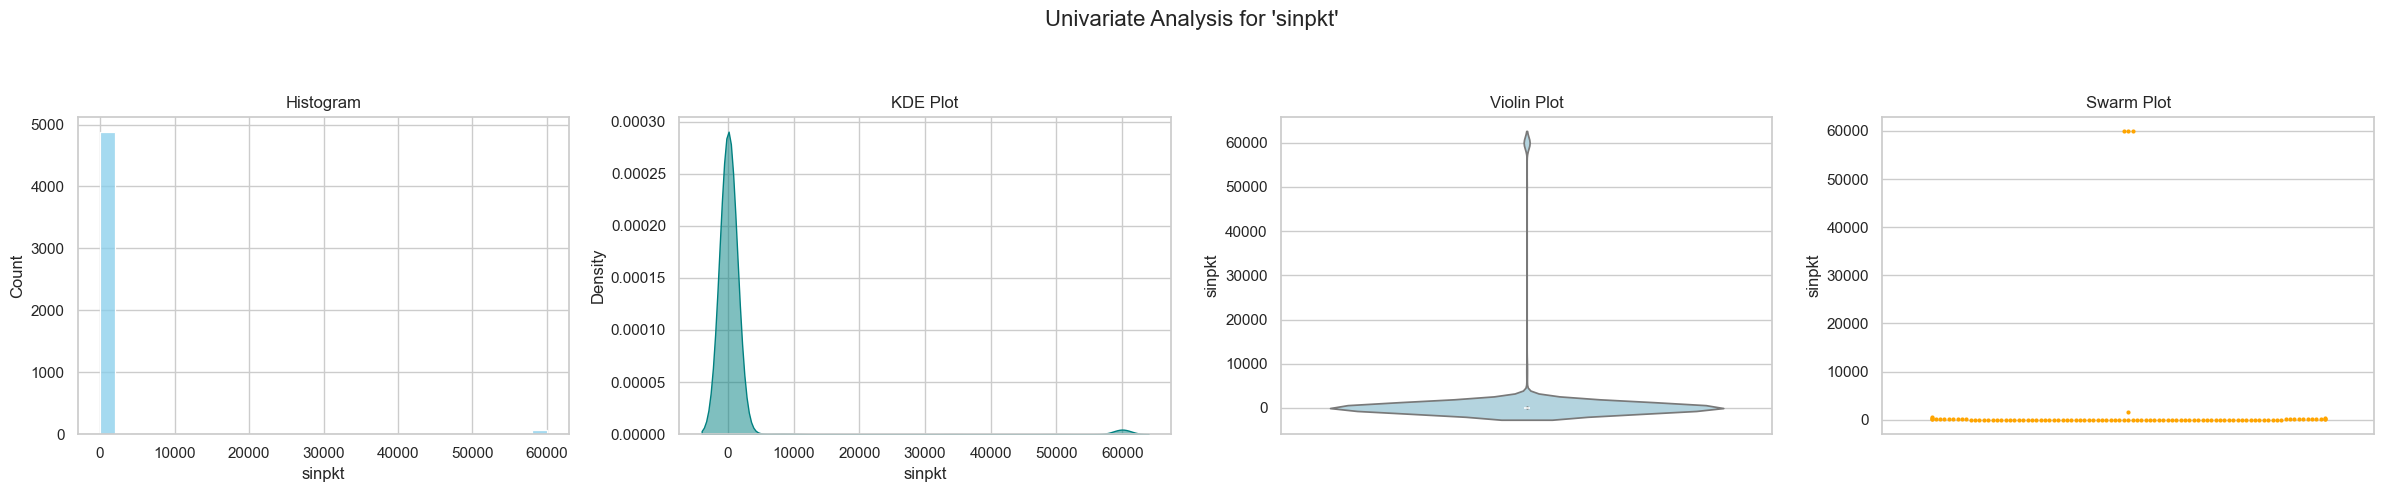

Plotting for: dinpkt


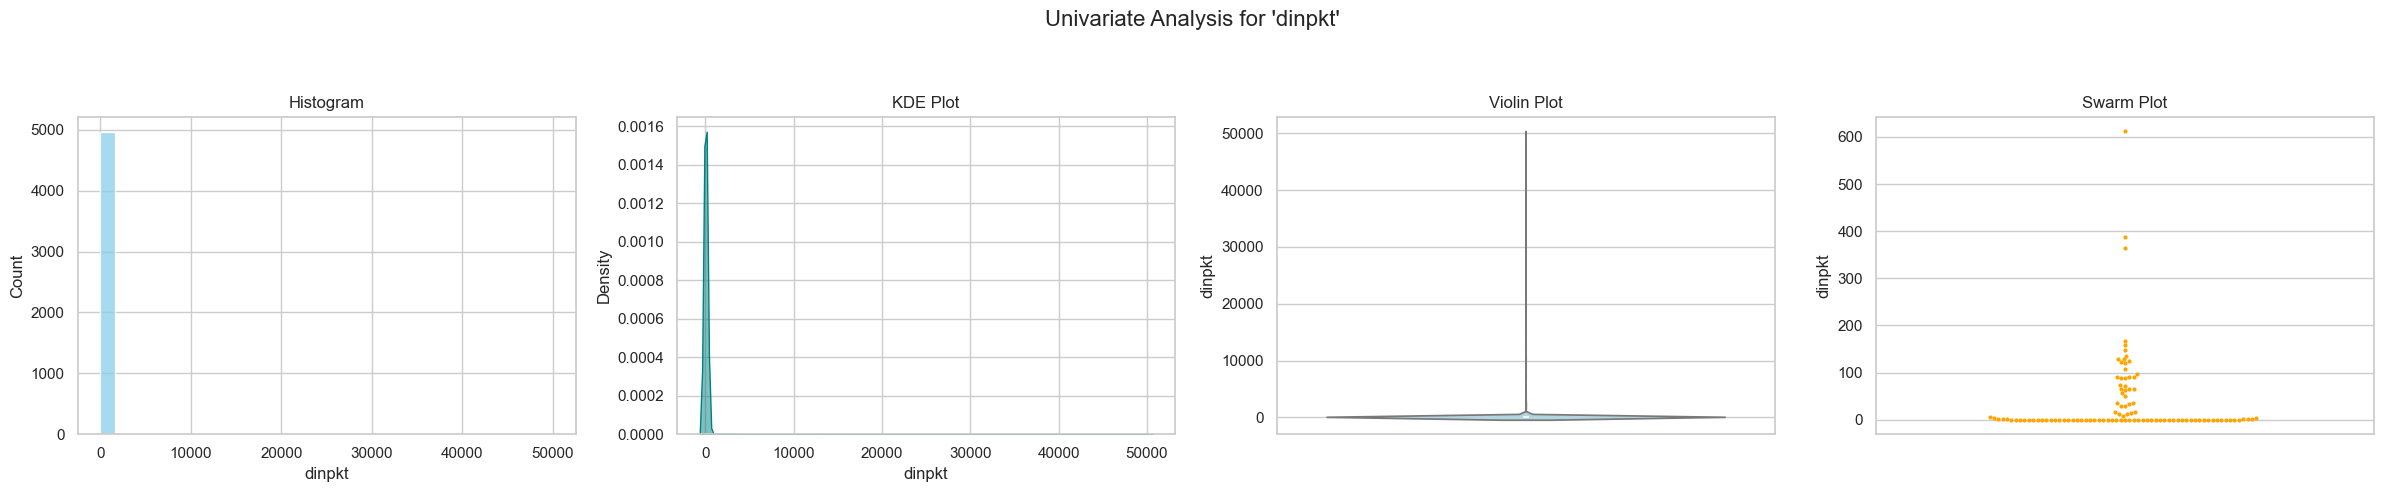

Plotting for: sjit


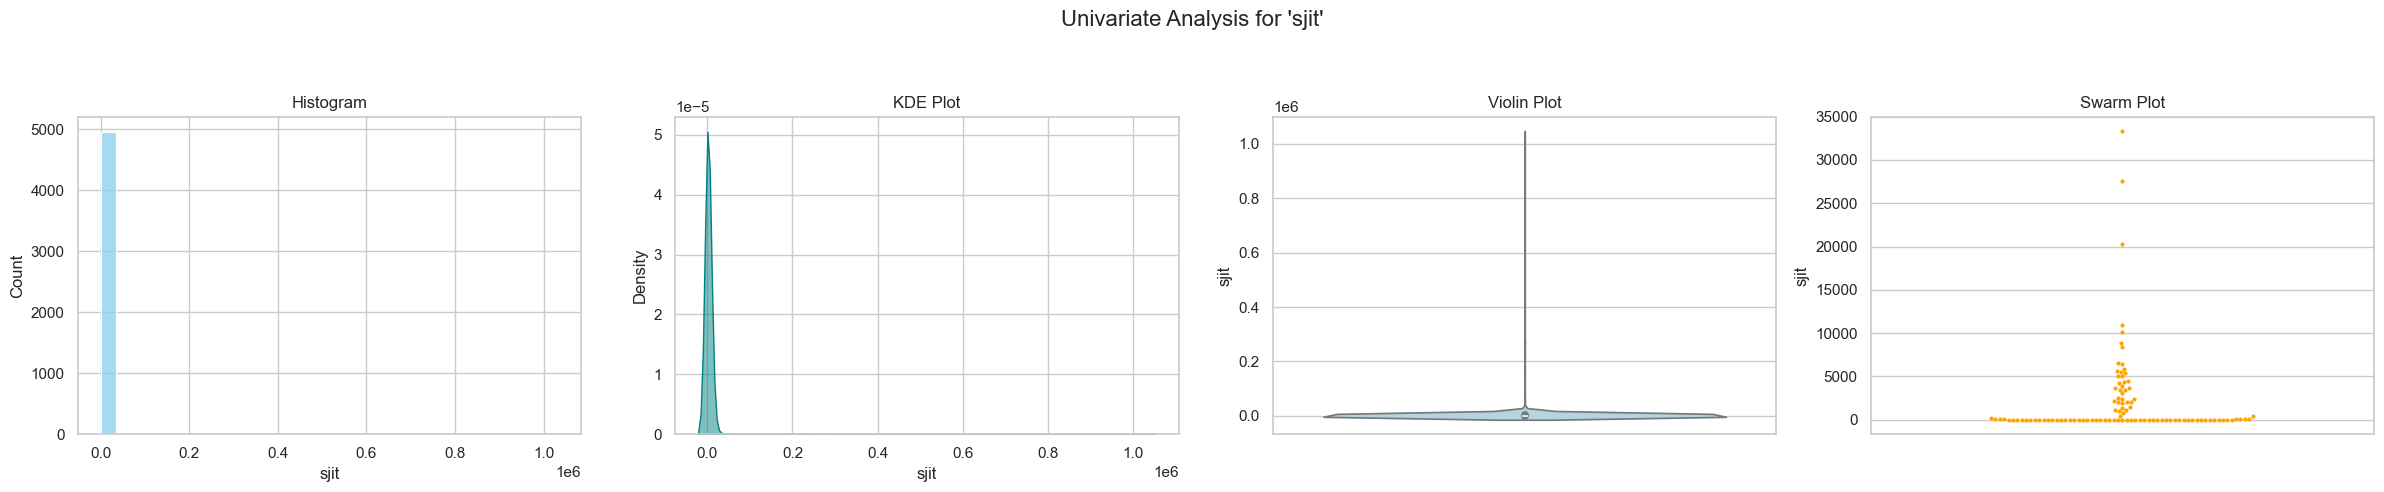

Plotting for: djit


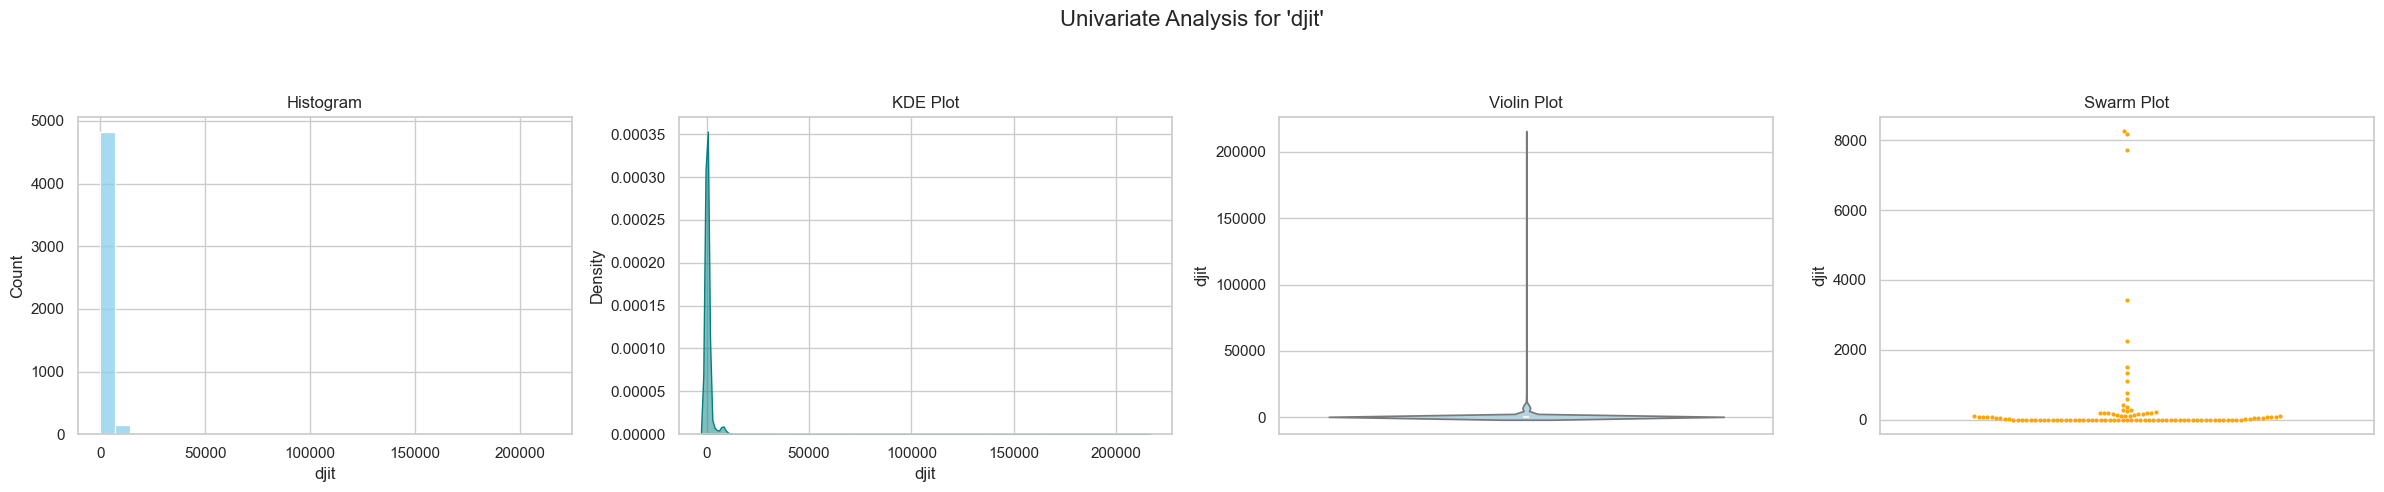

Plotting for: swin


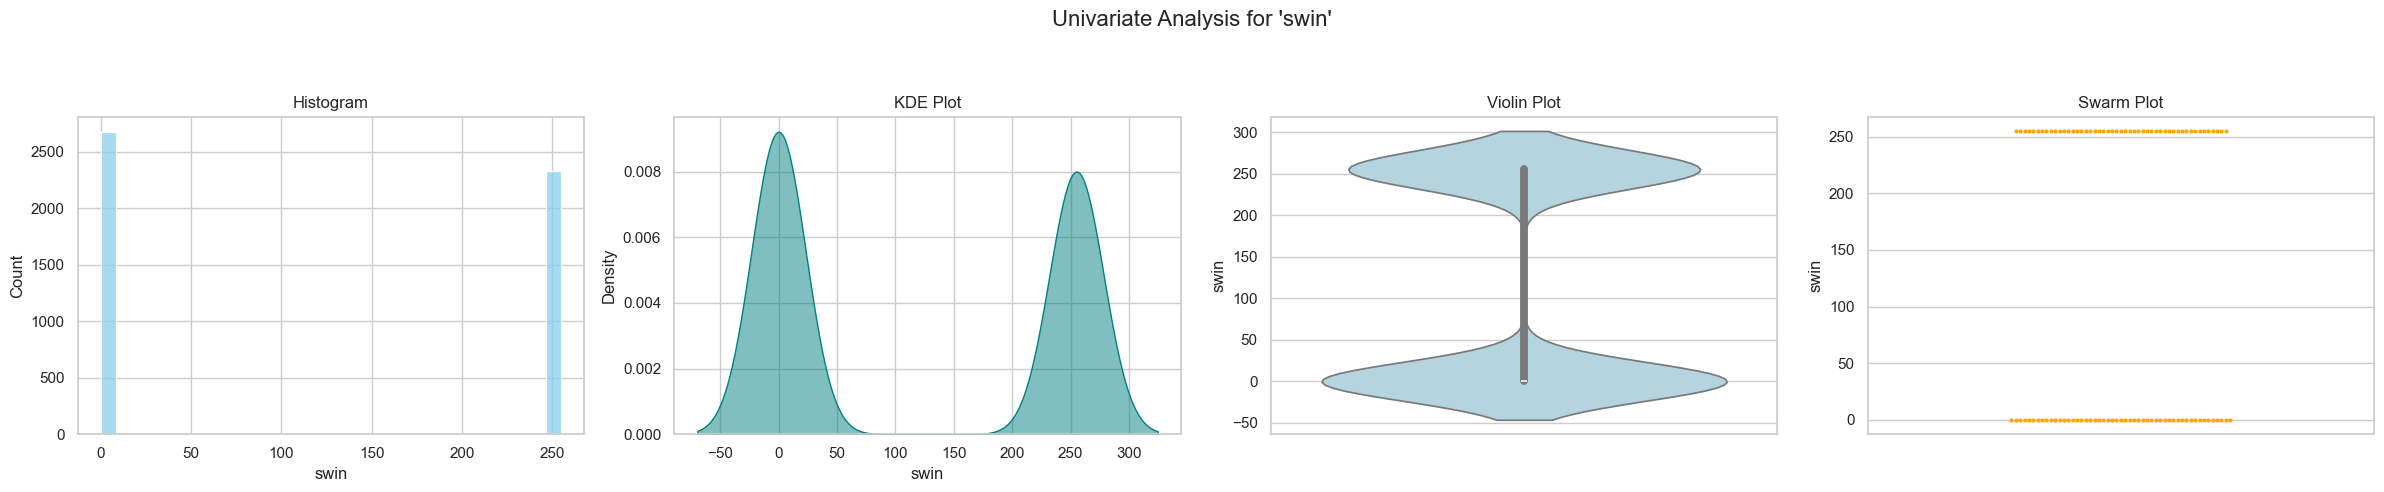

Plotting for: stcpb


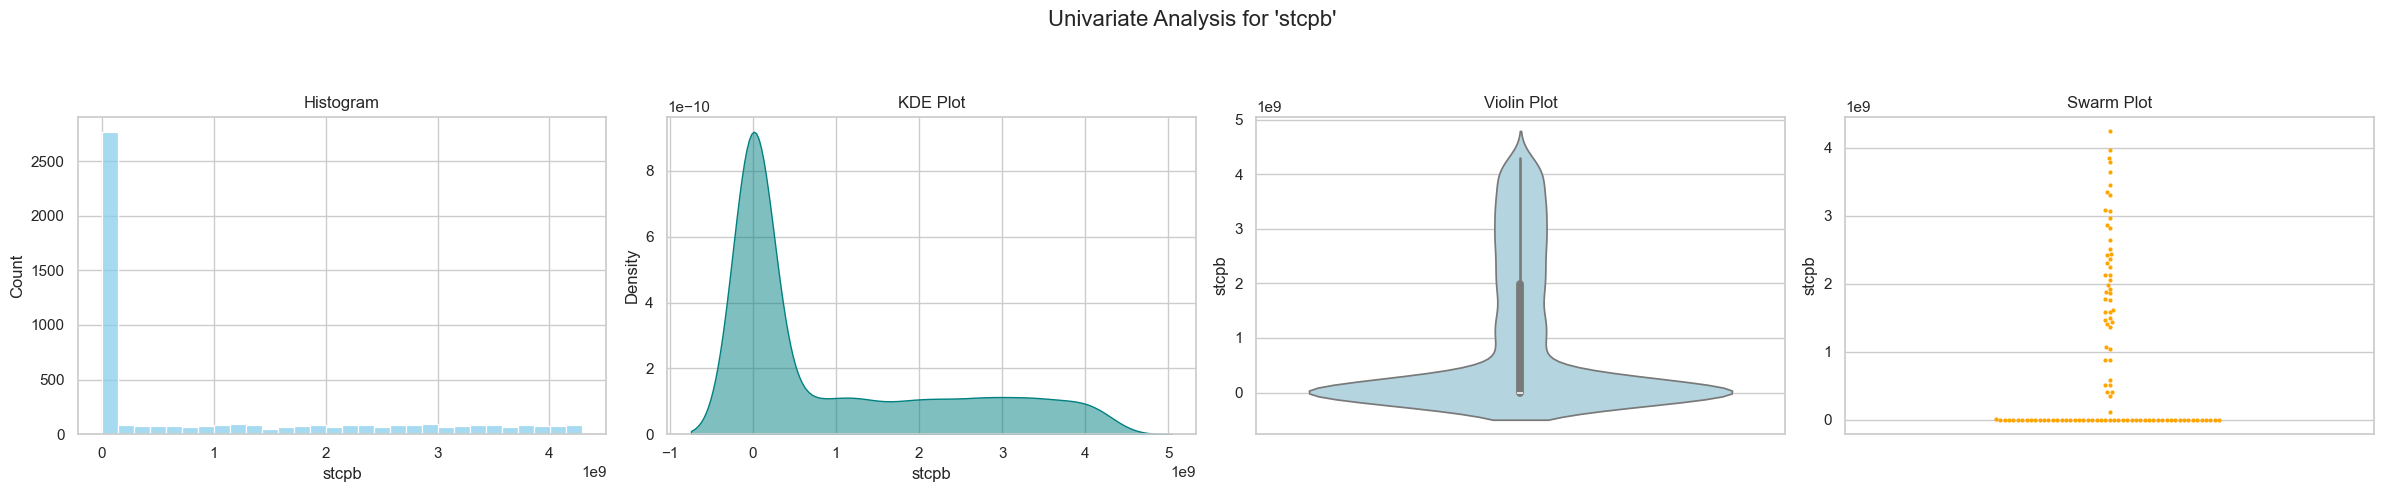

Plotting for: dtcpb


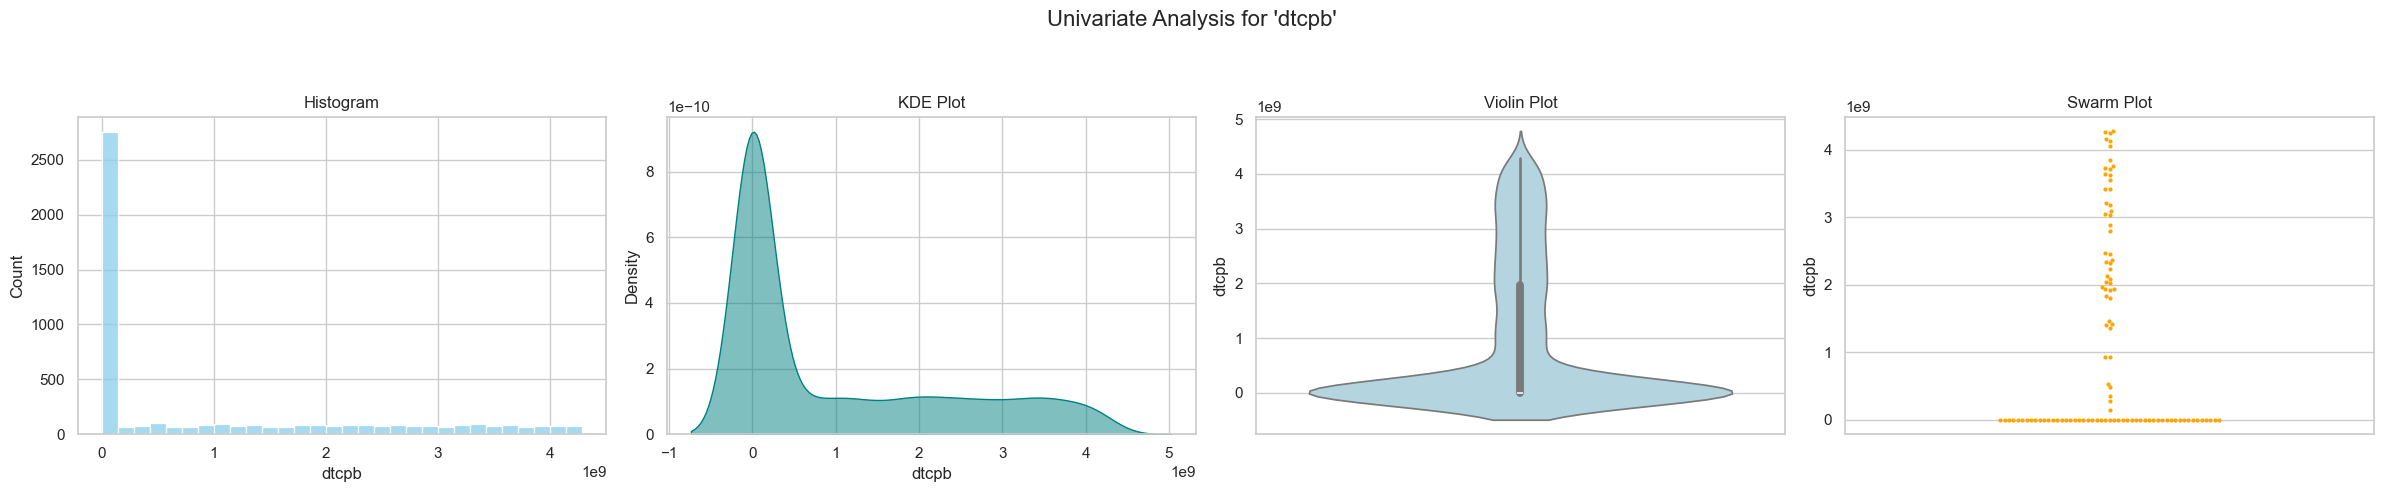

Plotting for: dwin


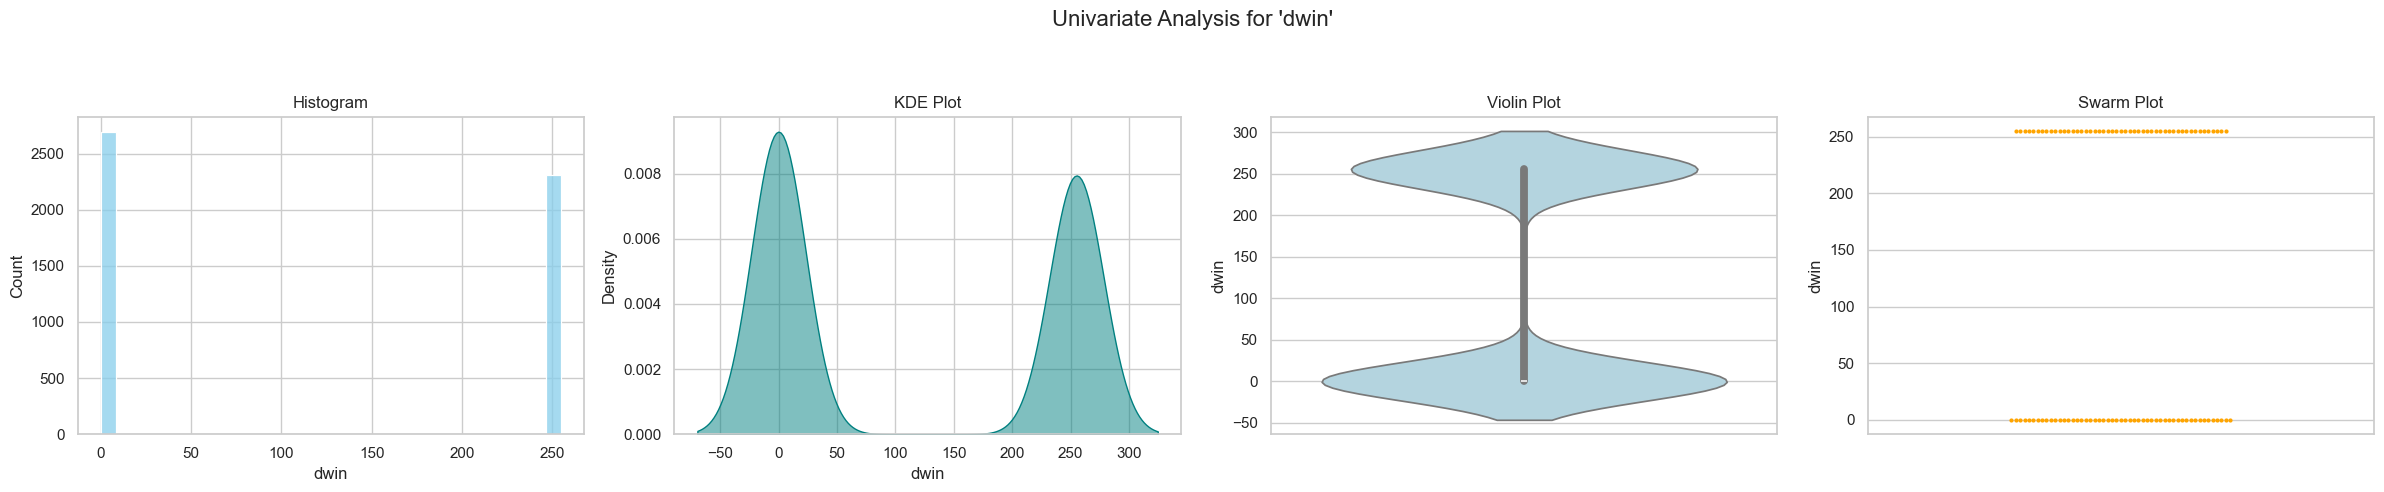

Plotting for: tcprtt


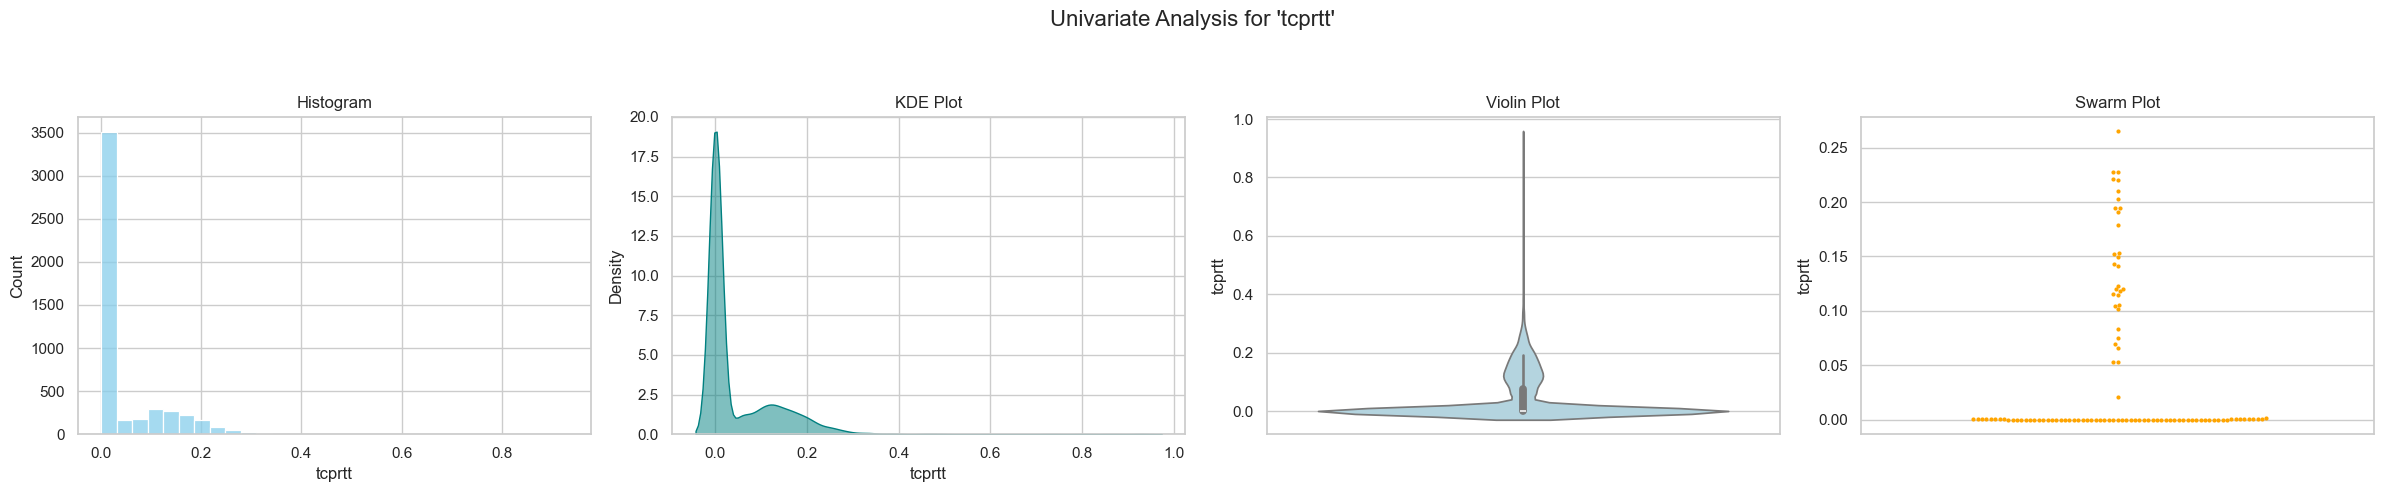

Plotting for: synack


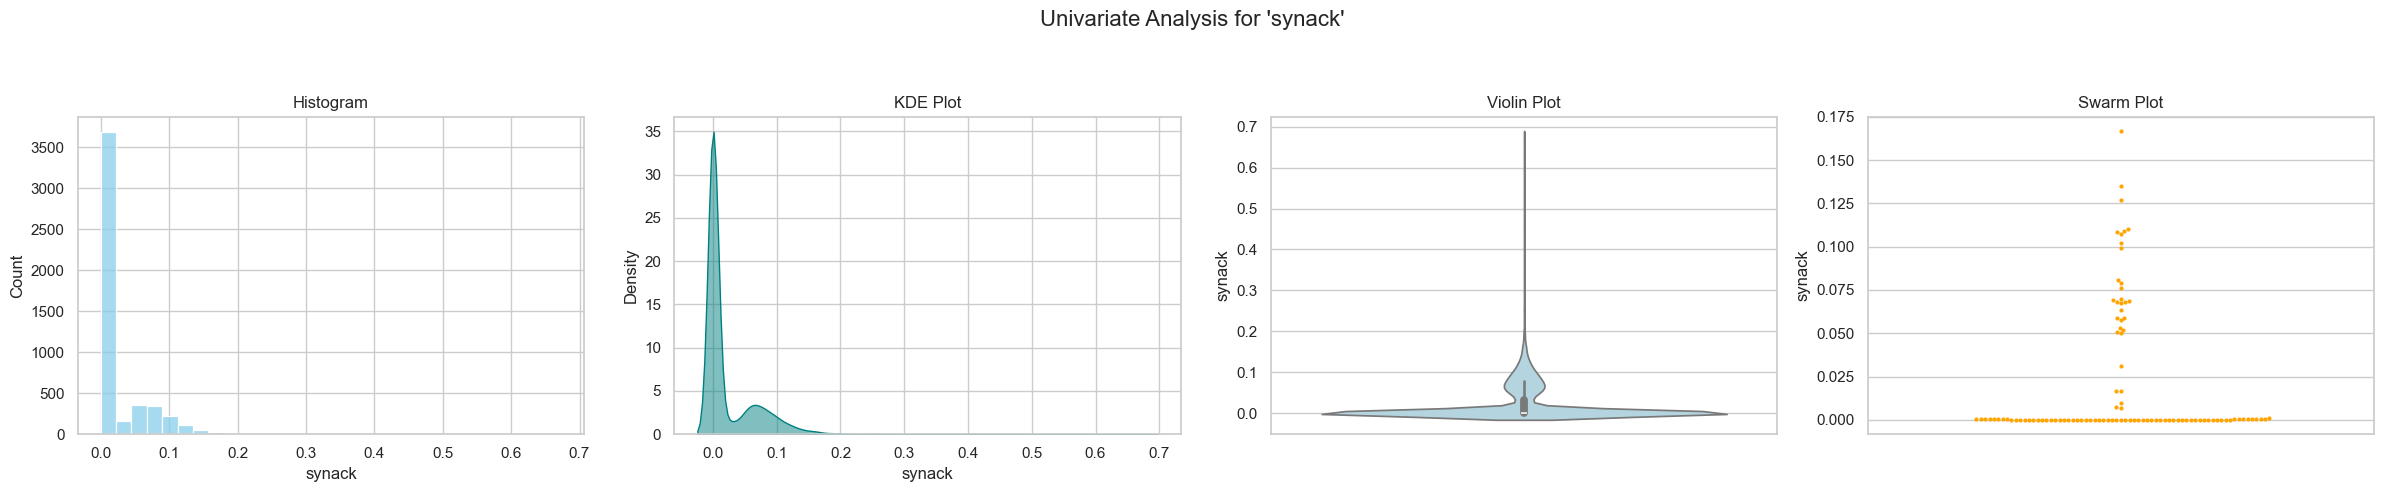

Plotting for: ackdat


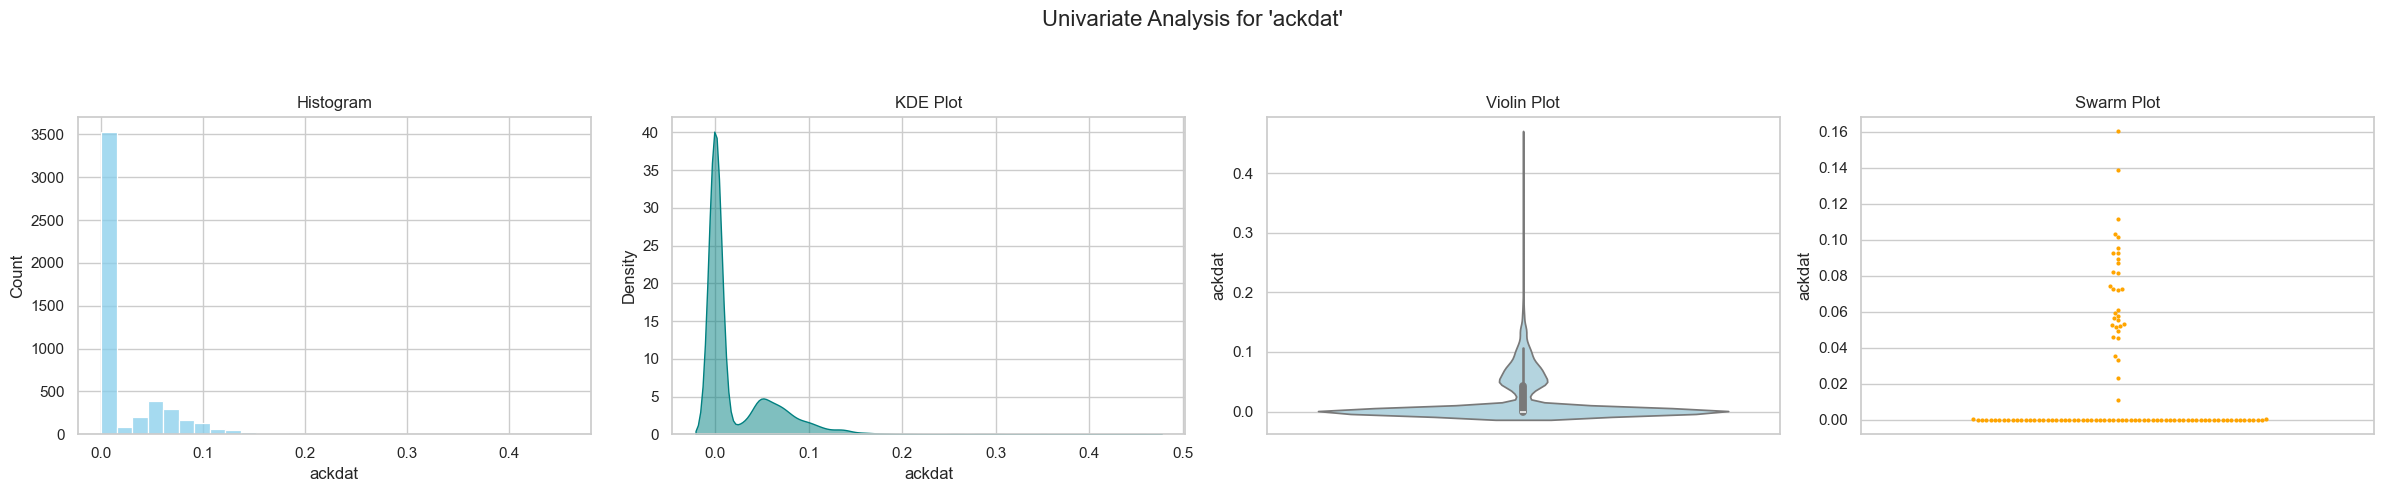

Plotting for: smean


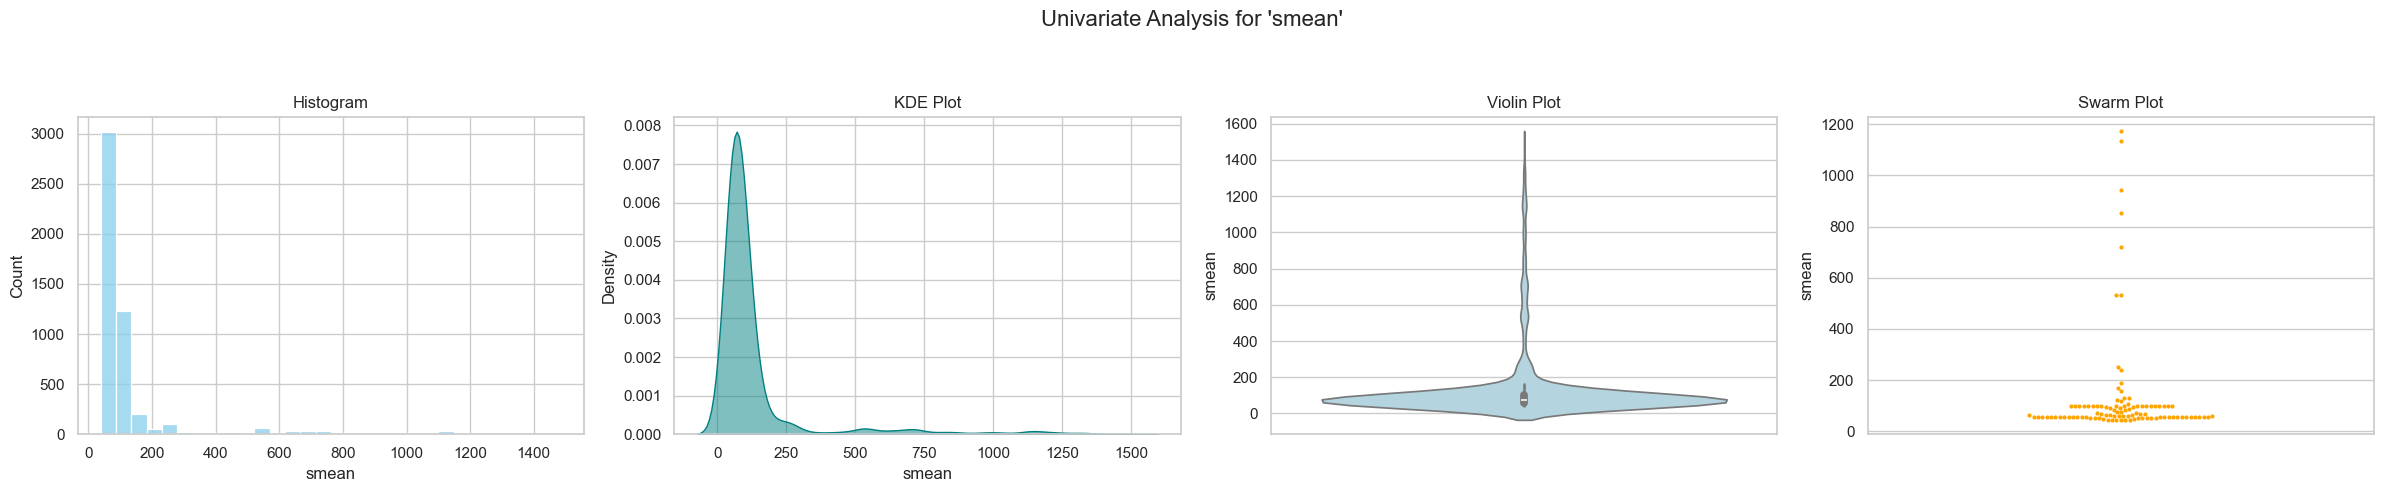

Plotting for: dmean


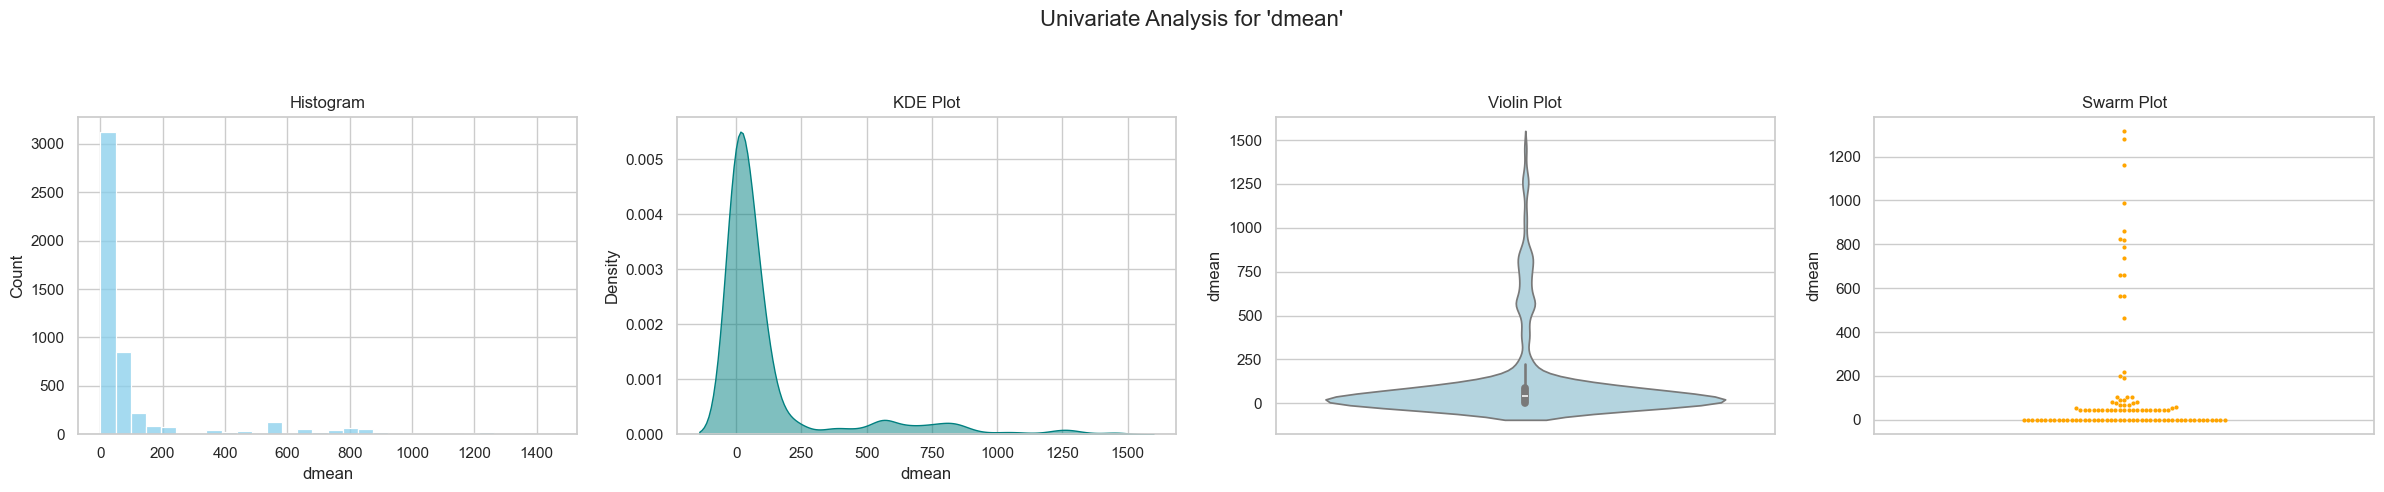

Plotting for: trans_depth


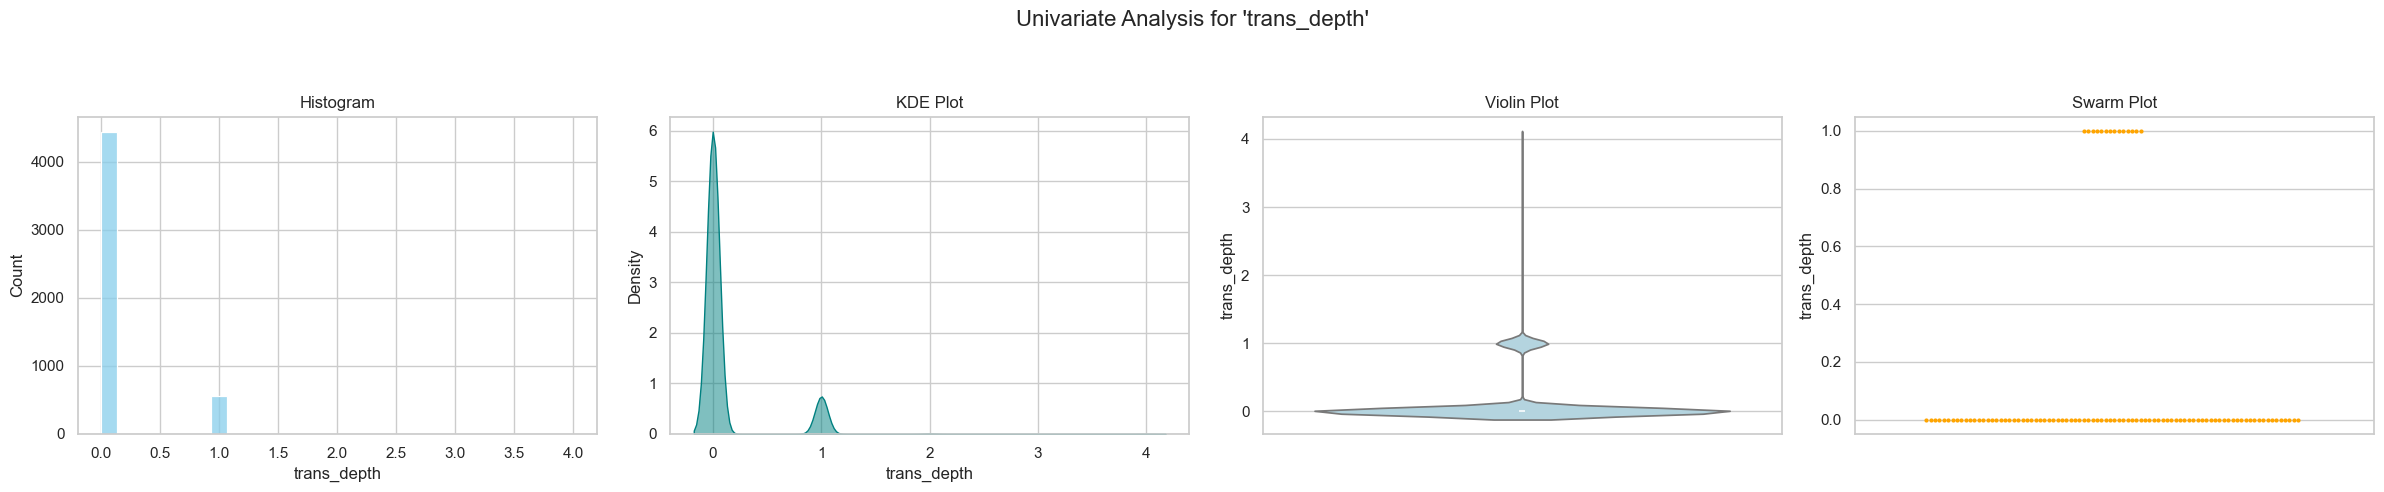

Plotting for: response_body_len


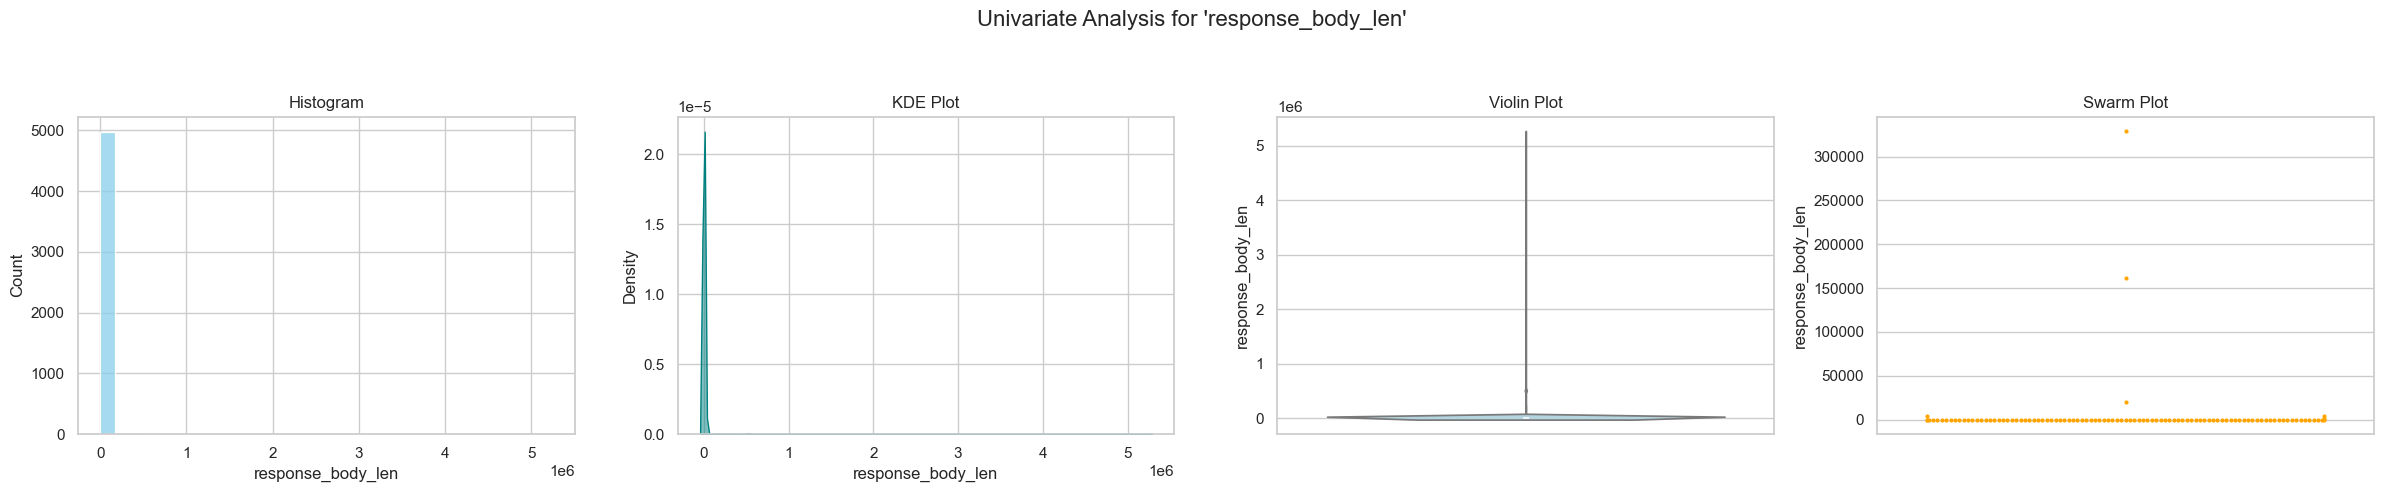

Plotting for: ct_src_dport_ltm


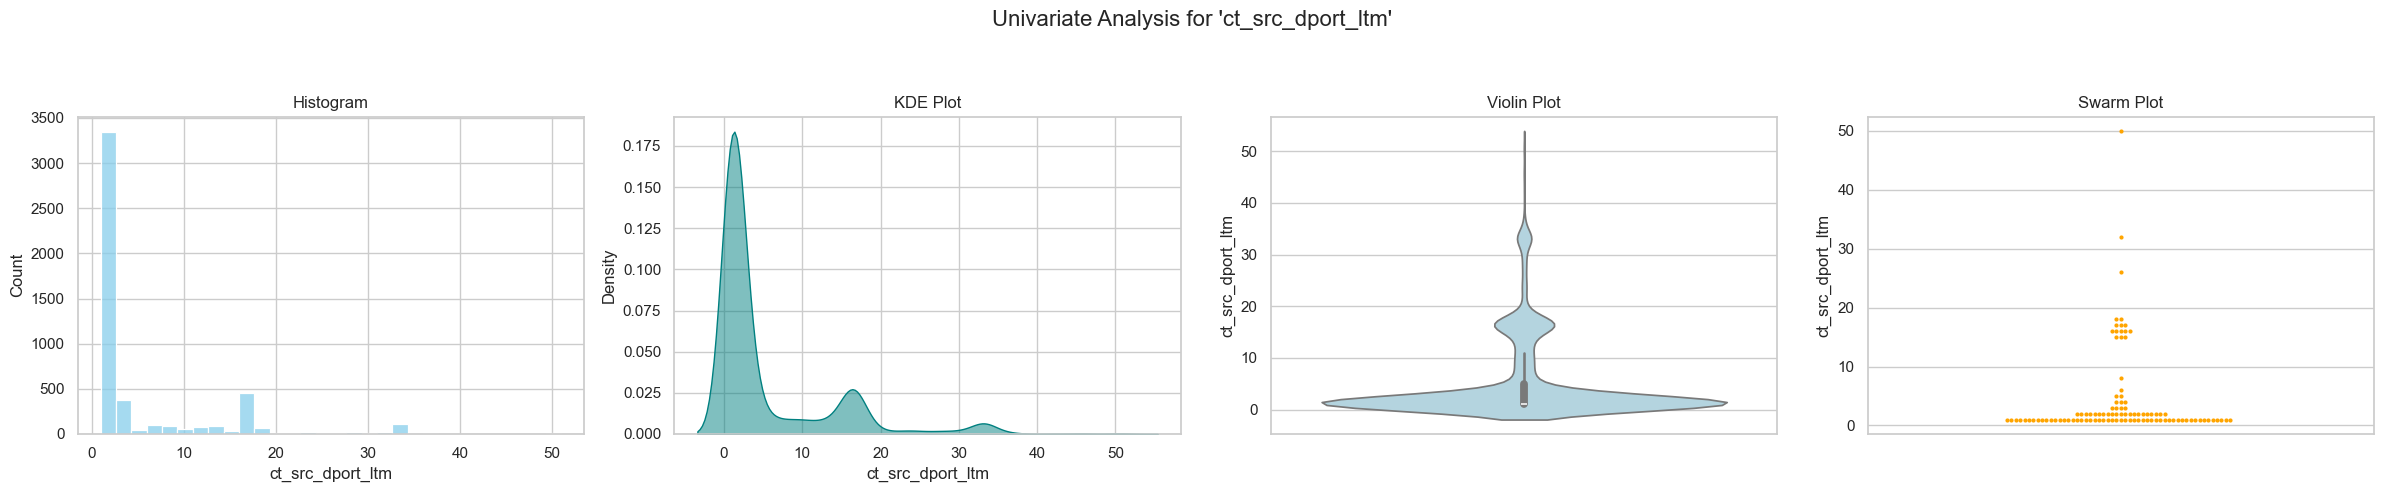

Plotting for: ct_dst_sport_ltm


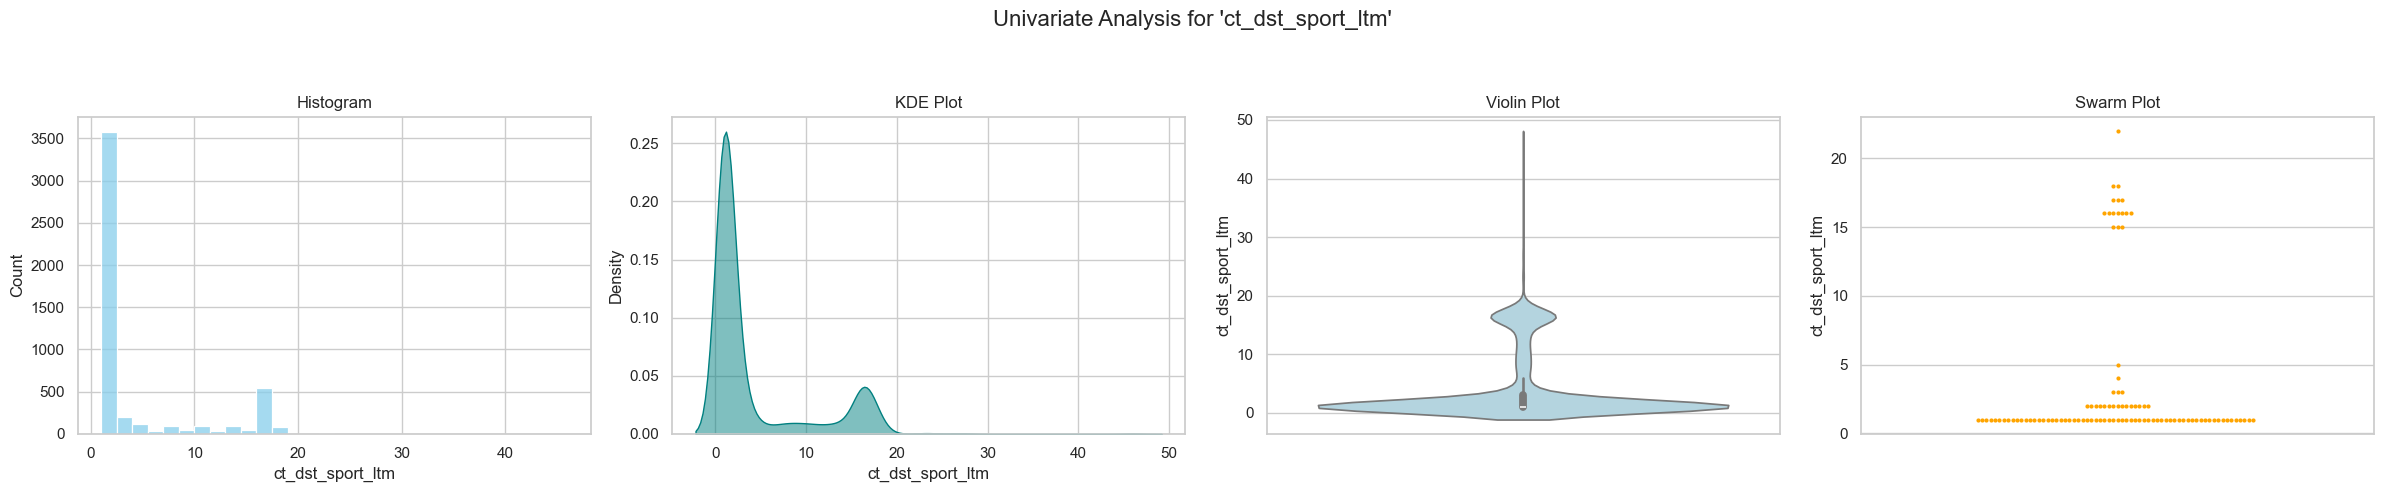

Plotting for: is_ftp_login


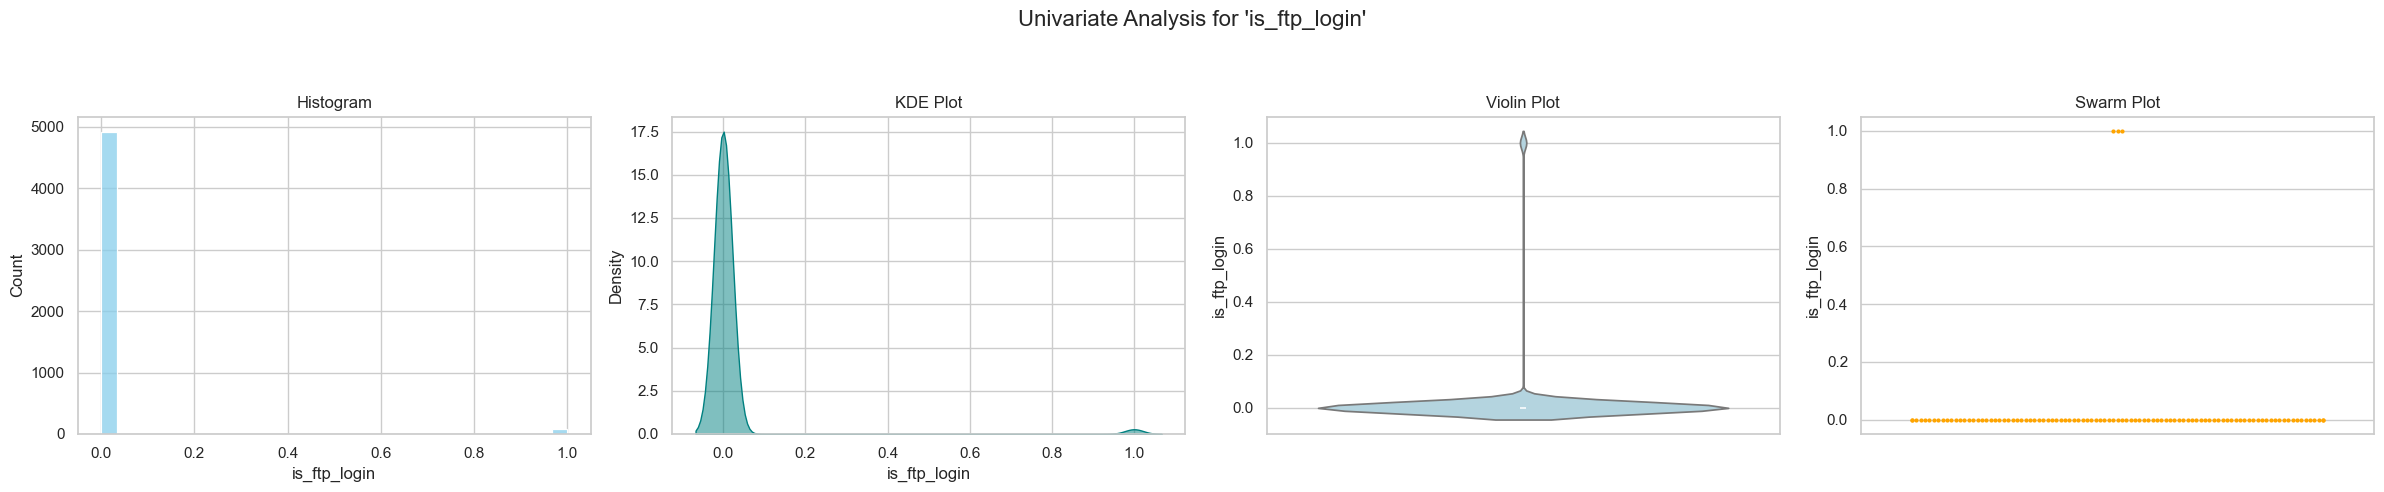

Plotting for: ct_ftp_cmd


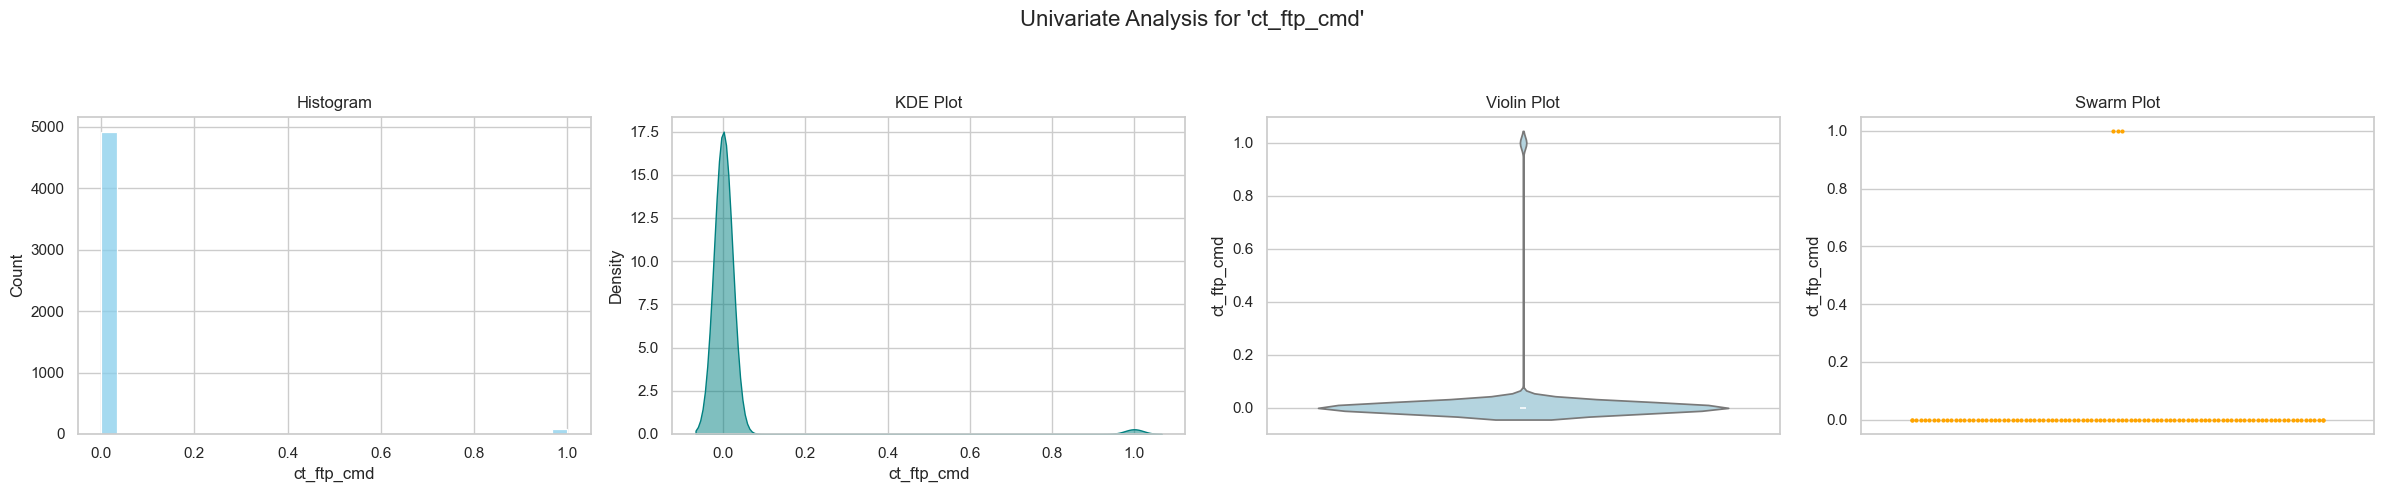

Plotting for: ct_flw_http_mthd


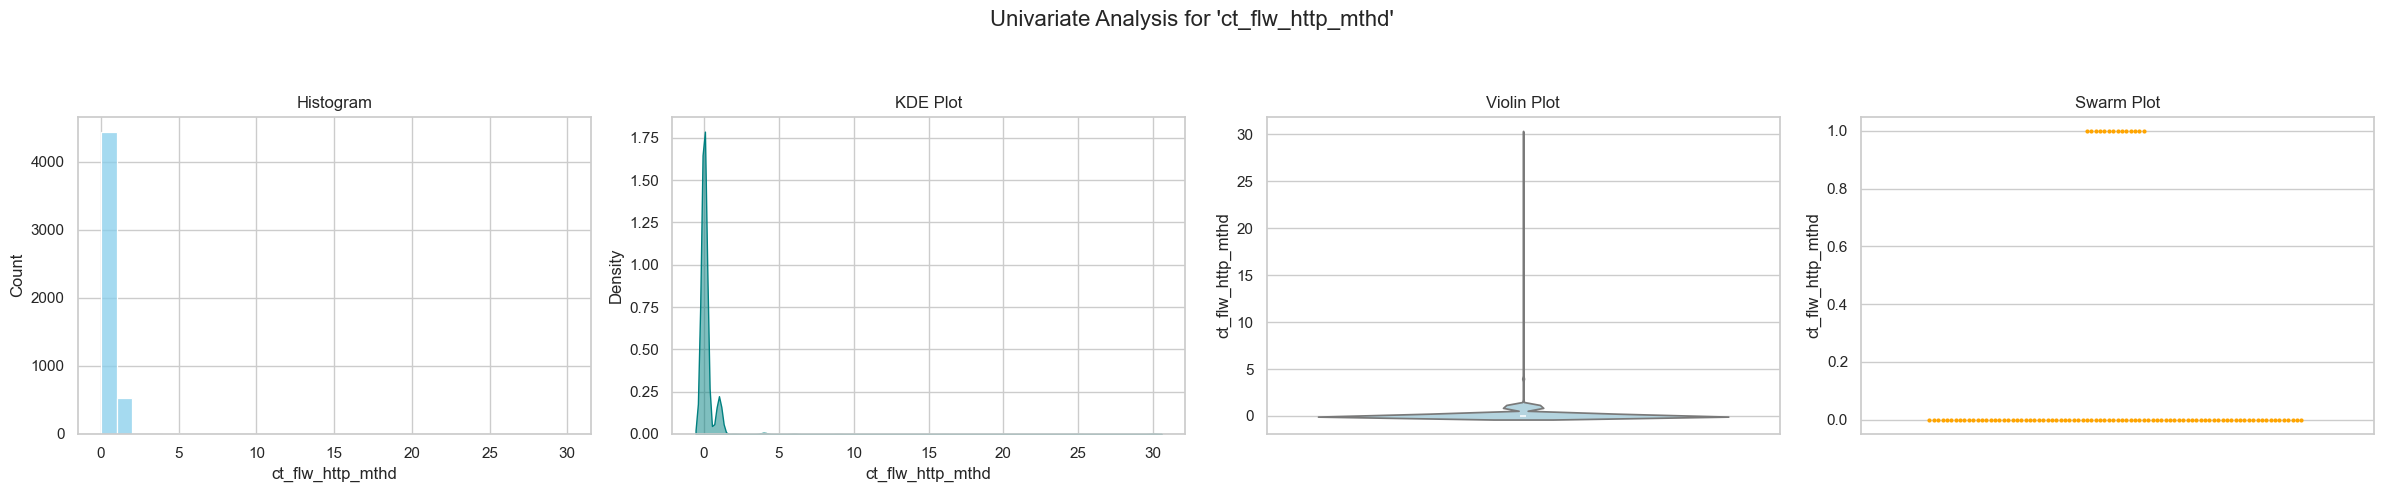

Plotting for: is_sm_ips_ports


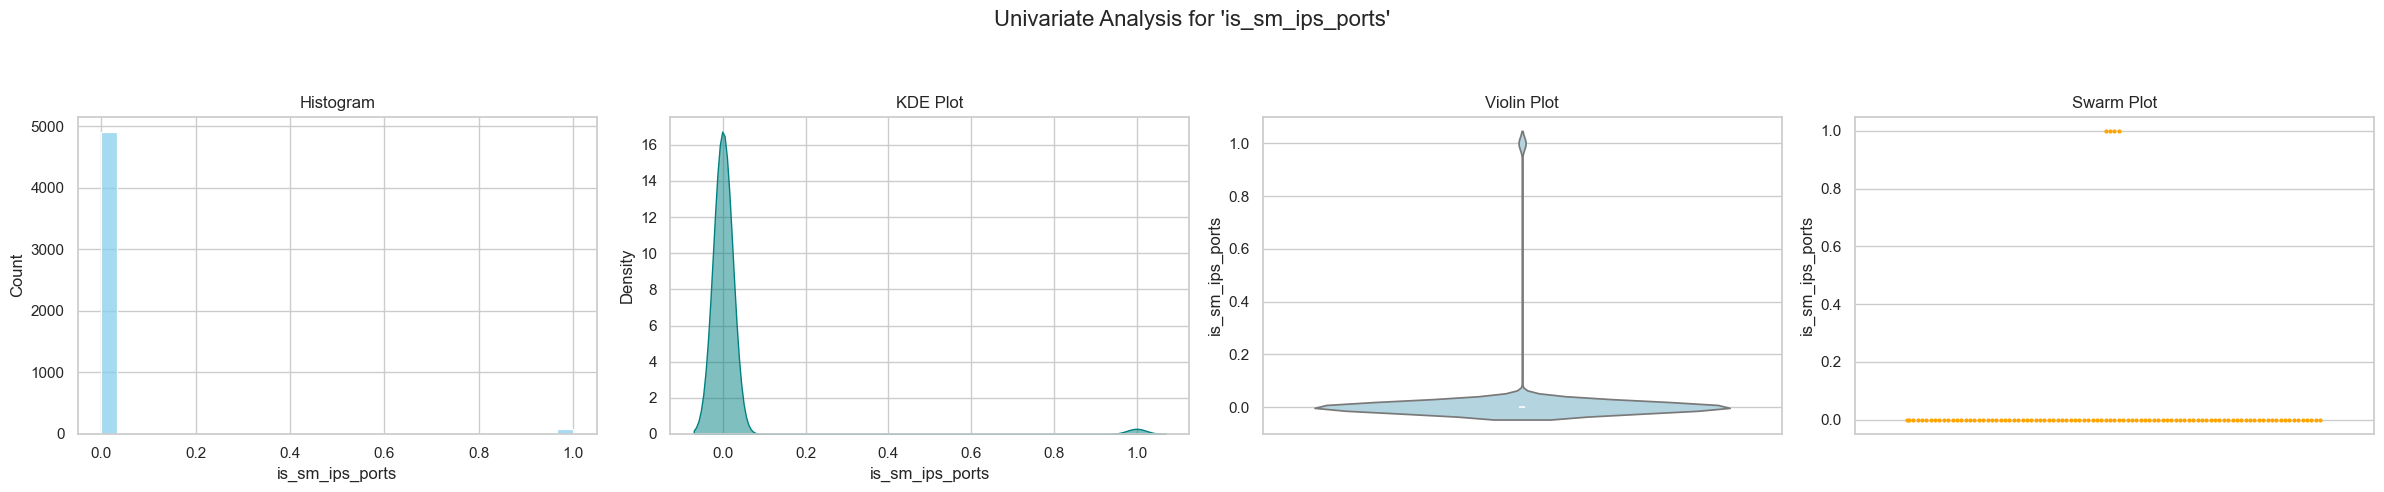

Plotting for: label


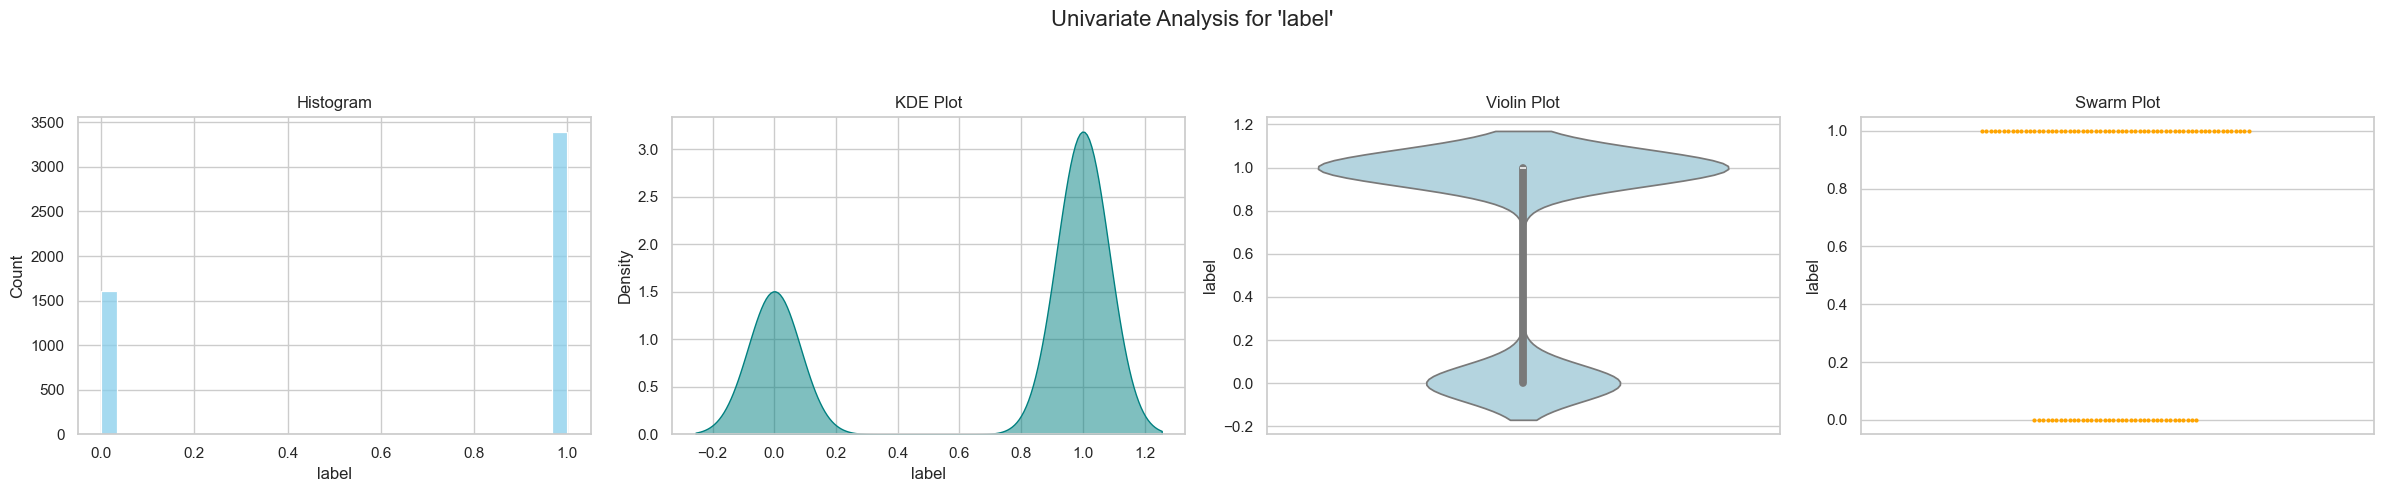

In [31]:
## Numeric Feature Distribution Analysis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Numeric columns
numeric_columns = [
    'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss',
    'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack',
    'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm',
    'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
    'is_sm_ips_ports', 'label'
]

# Sample the dataset
df_sample = df_unsw.sample(n=min(5000, len(df_unsw)), random_state=42)

# Loop through each numeric column
for col in numeric_columns:
    print(f"Plotting for: {col}")
    
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    fig.suptitle(f"Univariate Analysis for '{col}'", fontsize=16)

    # Histogram
    sns.histplot(data=df_sample, x=col, bins=30, color='skyblue', ax=axes[0])
    axes[0].set_title("Histogram")
    axes[0].set_xlabel(col)

    # KDE Plot
    sns.kdeplot(data=df_sample, x=col, fill=True, color='teal', alpha=0.5, ax=axes[1])
    axes[1].set_title("KDE Plot")
    axes[1].set_xlabel(col)

    # Violin Plot
    sns.violinplot(data=df_sample, y=col, color='lightblue', ax=axes[2])
    axes[2].set_title("Violin Plot")
    axes[2].set_ylabel(col)

    # Swarm Plot
    # Use only 500 points to avoid overcrowding in swarm
    df_swarm = df_sample[[col]].dropna().sample(n=min(100, len(df_sample)), random_state=42)
    sns.swarmplot(data=df_swarm, y=col, color='orange', size=3, ax=axes[3])
    axes[3].set_title("Swarm Plot")
    axes[3].set_ylabel(col)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


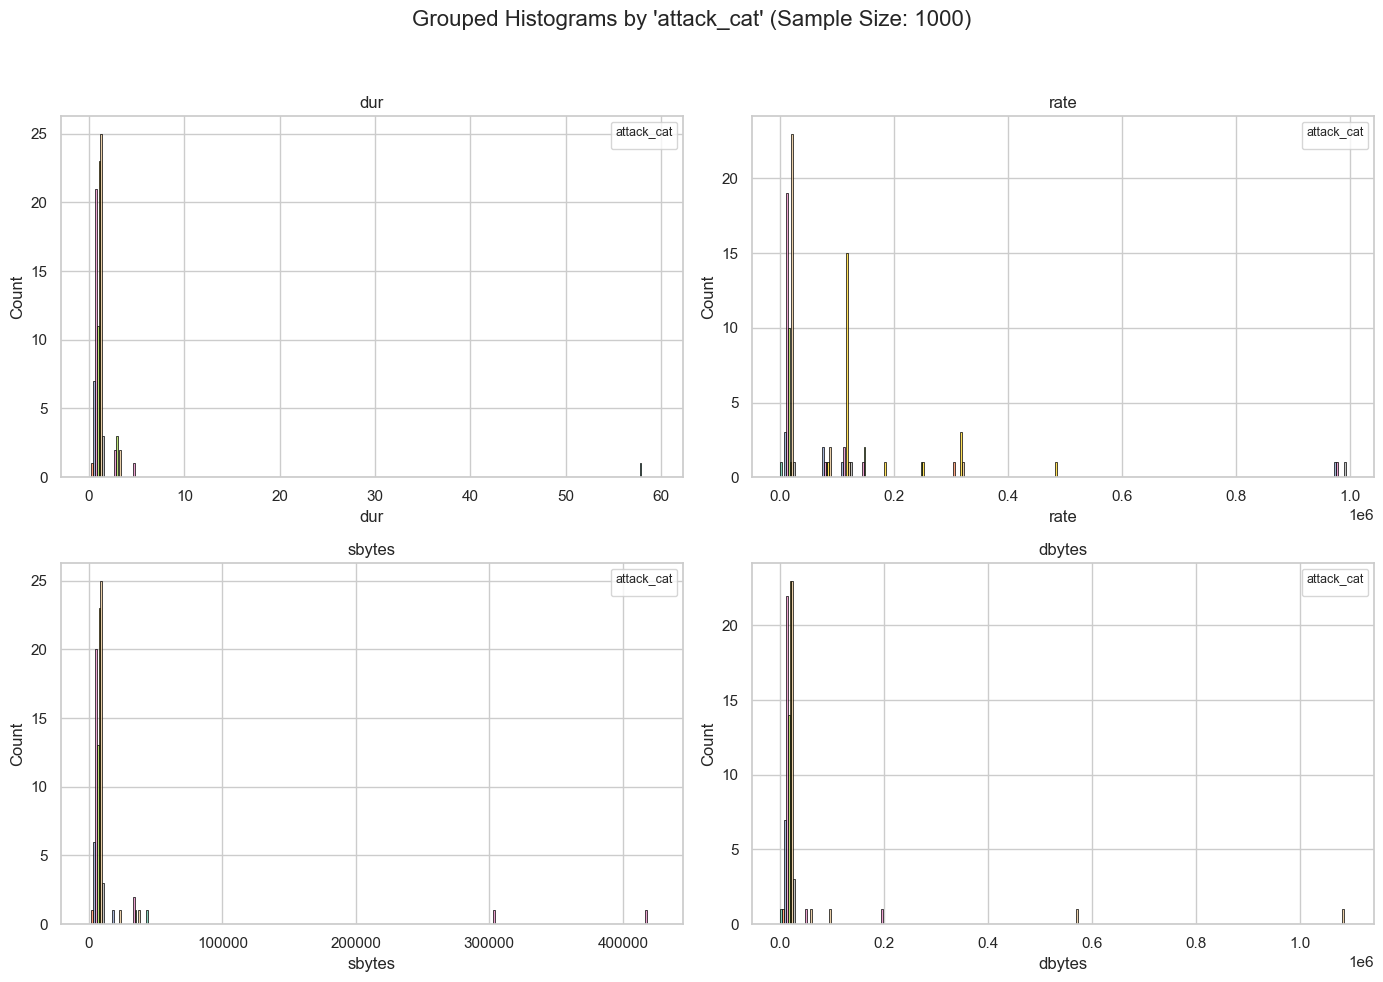

In [32]:
## Grouped Distribution Analysis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define numeric columns and grouping column
numeric_columns = ['dur', 'rate', 'sbytes', 'dbytes']
group_by_col = 'attack_cat'

# Sample the dataset for grouped histogram visualization

df_sample = df_unsw.sample(n=min(100, len(df_unsw)), random_state=42)

# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Grouped Histograms by '{group_by_col}' (Sample Size: 1000)", fontsize=16)

# Flatten axes array for easier indexing
axes = axes.flatten()

# Loop and plot each numeric column
for i, col in enumerate(numeric_columns):
    sns.histplot(
        data=df_sample,
        x=col,
        hue=group_by_col,
        multiple='dodge',
        palette='Set2',
        bins=30,
        ax=axes[i],
        edgecolor='black',   # Add edge color for better bar visibility
        linewidth=0.5,       # Thin border lines
        alpha=0.8            # Slightly opaque bars for clarity
    )
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend(title=group_by_col, fontsize=8, title_fontsize=9, loc='best')

# Remove any unused subplot axes if needed
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


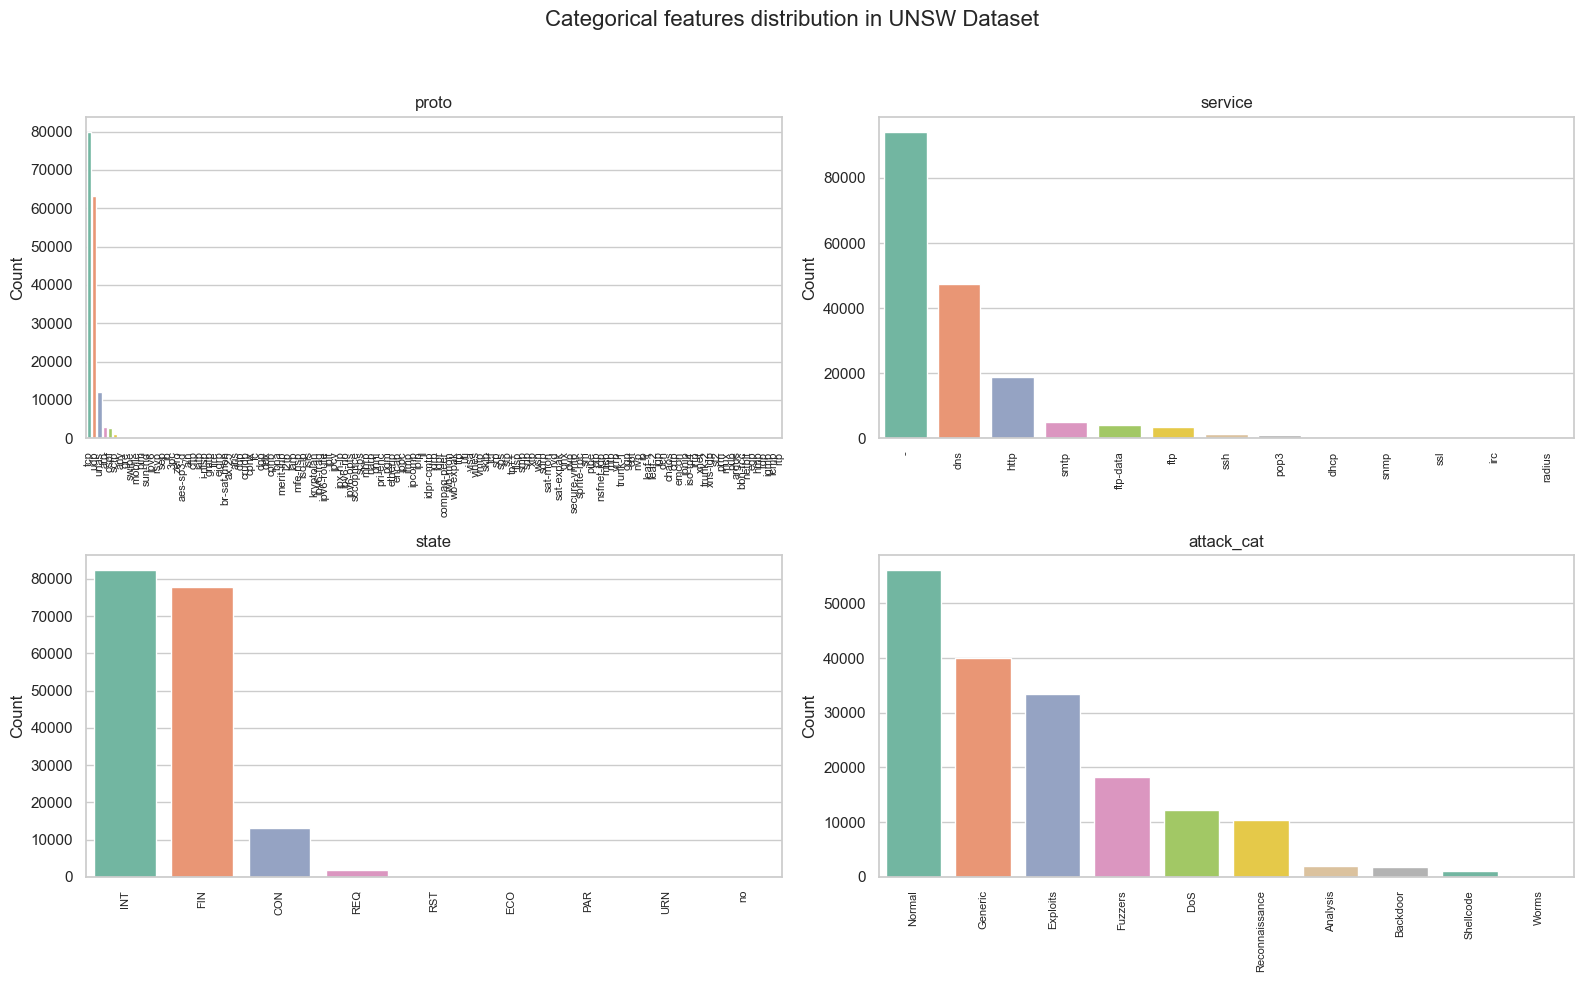

In [33]:
## Categorical Count Analysis 
 # Categorical columns
categorical_columns = ['proto', 'service', 'state', 'attack_cat']

# Set seaborn style
sns.set(style="whitegrid")

# Create subplots: 2 rows, 2 columns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Categorical features distribution in UNSW Dataset", fontsize=16)

# Flatten axes for easy iteration
axes = axes.flatten()

# Loop through each column and plot on respective axis
for i, col in enumerate(categorical_columns):
    sns.countplot(
        data=df_unsw,
        x=col,
        order=df_unsw[col].value_counts().index,
        palette='Set2',
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=90,labelsize=8)

# Hide any unused subplots if categorical_columns < 4 (optional)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [34]:
## Summary Statistics
import pandas as pd

numeric_columns_unsw = df_unsw.select_dtypes(include=['number']).columns.tolist()
categorical_columns_unsw = df_unsw.select_dtypes(include=['object']).columns.tolist()

summary_list = []

# Numeric columns: mean, median, mode
for col in numeric_columns_unsw:
    mean_val = df_unsw[col].mean()
    median_val = df_unsw[col].median()
    mode_val = df_unsw[col].mode().values[0] if not df_unsw[col].mode().empty else None
    summary_list.append({
        'Column': col,
        'Type': 'Numeric',
        'Mean': round(mean_val, 2),
        'Median': round(median_val, 2),
        'Mode': mode_val
    })

# Categorical columns: mode only
for col in categorical_columns_unsw:
    mode_val = df_unsw[col].mode().values[0] if not df_unsw[col].mode().empty else None
    summary_list.append({
        'Column': col,
        'Type': 'Categorical',
        'Mean': None,
        'Median': None,
        'Mode': mode_val
    })

# Create DataFrame
summary_df_unsw = pd.DataFrame(summary_list)

summary_df_unsw


,Column,Type,Mean,Median,Mode
0,dur,Numeric,1.360000e+00,0.000000,9.000000e-06
1,spkts,Numeric,2.030000e+01,2.000000,2.000000e+00
2,dpkts,Numeric,1.897000e+01,2.000000,0.000000e+00
3,sbytes,Numeric,8.844840e+03,430.000000,1.140000e+02
4,dbytes,Numeric,1.492892e+04,164.000000,0.000000e+00
5,rate,Numeric,9.540618e+04,3225.810059,1.111111e+05
6,sload,Numeric,7.345403e+07,879674.750000,5.066666e+07
7,dload,Numeric,6.712056e+05,1447.020020,0.000000e+00
8,sloss,Numeric,4.950000e+00,0.000000,0.000000e+00
9,dloss,Numeric,6.950000e+00,0.000000,0.000000e+00


In [35]:
## Minimum and Maximum Value Review

unsw_numeric_columns = df_unsw.select_dtypes(include="number").columns

min_max_unsw = pd.DataFrame({
    "Minimum": df_unsw[unsw_numeric_columns].min(),
    "Maximum": df_unsw[unsw_numeric_columns].max()
})

min_max_unsw

,Minimum,Maximum
dur,0.0,5.999999e+01
spkts,1.0,9.616000e+03
dpkts,0.0,1.097400e+04
sbytes,28.0,1.296523e+07
dbytes,0.0,1.465555e+07
rate,0.0,1.000000e+06
sload,0.0,5.988000e+09
dload,0.0,2.242273e+07
sloss,0.0,4.803000e+03
dloss,0.0,5.484000e+03


In [36]:
import pandas as pd

numeric_columns_unsw = df_unsw.select_dtypes(include=['number']).columns.tolist()

## Outlier Review
Q1 = df_unsw[numeric_columns_unsw].quantile(0.25)
Q3 = df_unsw[numeric_columns_unsw].quantile(0.75)
IQR = Q3 - Q1

# Detect outliers
outlier_mask = ((df_unsw[numeric_columns_unsw] < (Q1 - 1.5 * IQR)) | (df_unsw[numeric_columns_unsw] > (Q3 + 1.5 * IQR)))

# Find columns with any outliers
cols_with_outliers = outlier_mask.any()
cols_outlier_list = cols_with_outliers[cols_with_outliers].index.tolist()

# Create DataFrame to display columns with outliers
outliers_df = pd.DataFrame({
    'Columns With Outliers': cols_outlier_list
})

outliers_df


,Columns With Outliers
0,dur
1,spkts
2,dpkts
3,sbytes
4,dbytes
5,rate
6,sload
7,dload
8,sloss
9,dloss


### UNSW-NB15 Dataset Conclusion

The UNSW-NB15 dataset is useful for network-level intrusion detection analysis because it contains traffic-flow features, categorical network attributes, attack categories, and binary attack labels.

The univariate plots show that many numeric network-flow features are skewed, discrete, or contain extreme values. Features such as byte counts, packet counts, loss counts, timing measures, and traffic rates may show strong outlier behavior.

In cybersecurity data, outliers should not be removed automatically because unusual values may represent attack behavior, scanning activity, data exfiltration, or denial-of-service patterns.

The categorical bar plots for protocol, service, state, and attack category help show how network activity and attack labels are distributed across the dataset.

Overall, UNSW-NB15 is one of the stronger datasets in this project for network-level intrusion detection, but its skewed distributions, outliers, and class imbalance require careful preprocessing, scaling, and model evaluation.

### Overall Univariate EDA Conclusion

Across the three cybersecurity datasets, the univariate analysis shows that the data are usable for academic machine learning analysis, but each dataset has different strengths and limitations.

BETH is strongest for host-level behavior analysis because it includes process, user, host, event, suspicious-label, and malicious-label information.

UNSW-NB15 is strongest for network-level intrusion detection because it includes detailed network-flow features and attack labels.

The Cybersecurity Attacks dataset is useful for exploratory analysis and pipeline testing, but it should be interpreted more cautiously because of synthetic patterns and dataset-quality limitations.

Most cybersecurity features are not normally distributed. Skewness, multimodal patterns, outliers, and class imbalance are expected in threat-detection data. These findings support the need for careful preprocessing, feature engineering, scaling, and model evaluation using metrics beyond accuracy.